___
___

# **🧭 EDA Fraud Challenge 2026**

___
___

In [1]:
# Librería Estándar
import os
import sys
from pathlib import Path

# Librerías de Terceros
import matplotlib.pyplot as plt
from IPython.display    import display
from matplotlib.colors  import LinearSegmentedColormap, to_hex
from matplotlib.lines   import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker  import FuncFormatter
import numpy  as np
import pandas as pd
from scipy.stats     import chi2_contingency, gaussian_kde
from sklearn.metrics import average_precision_score
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data.contract import DataContract
from data.prepare  import DatasetBuilder
from data.split    import TemporalSplitter

In [2]:
DATA_ROOT     = Path(os.environ.get('FRAUD_DATA_ROOT', PROJECT_ROOT / 'data'))
RAW_CSV       = DATA_ROOT / 'raw' / 'fraud_dataset_2026_.csv'
ARTIFACTS_EDA = PROJECT_ROOT / 'artifacts' / 'eda'
ARTIFACTS_EDA.mkdir(parents = True, exist_ok = True)
print(
    f'📂 Directorios Configurados:\n'
    f'   ├─ Project Root: {PROJECT_ROOT}\n'
    f'   ├─ Data Root   : {DATA_ROOT}\n'
    f'   ├─ Raw CSV     : {RAW_CSV}\n'
    f'   └─ EDA Output  : {ARTIFACTS_EDA}'
)

COLORS = {
    'paper'           : '#FCFCFB',
    'ink'             : '#1A1A1A',
    'muted'           : '#6B6A65',
    'grid'            : '#E4E3DC',
    'normal'          : '#2A9D5A',
    'fraud'           : '#E34948',
    'teal'            : '#5B8A9C',
    'amber'           : '#E4A853',
    'gray'            : '#B8B6AE',
    'id_like'         : '#D97860',
    'high_cardinality': '#C9A14A',
    'small_category'  : '#6FB08A',
}

COLOR_NORMAL = COLORS['normal']
COLOR_FRAUD  = COLORS['fraud']
COLOR_TEAL   = COLORS['teal']
COLOR_MUTED  = COLORS['muted']
COLOR_GRAY   = COLORS['gray']
RISK_CMAP    = LinearSegmentedColormap.from_list(
    'fraud_risk',
    [COLOR_NORMAL, COLORS['grid'], COLOR_FRAUD],
)
PCT = FuncFormatter(lambda value, _: f'{value:.0%}')

plt.rcParams.update({
    'figure.facecolor'  : COLORS['paper'],
    'axes.facecolor'    : COLORS['paper'],
    'savefig.facecolor' : COLORS['paper'],
    'savefig.dpi'       : 180,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.25,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'text.color'        : COLORS['ink'],
    'axes.labelcolor'   : COLORS['muted'],
    'xtick.color'       : COLORS['muted'],
    'ytick.color'       : COLORS['muted'],
    'axes.edgecolor'    : COLORS['grid'],
    'axes.linewidth'    : 1.0,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : COLORS['grid'],
    'grid.linewidth'    : 0.8,
    'legend.frameon'    : False,
})

pd.set_option('display.max_columns' , 50)
pd.set_option('display.max_colwidth', 120)

📂 Directorios Configurados:
   ├─ Project Root: g:\Otros ordenadores\Mi PC\Documentos\JOBS\Ofertas\MercadoLibre_Fraud
   ├─ Data Root   : g:\Otros ordenadores\Mi PC\Documentos\JOBS\Ofertas\MercadoLibre_Fraud\data
   ├─ Raw CSV     : g:\Otros ordenadores\Mi PC\Documentos\JOBS\Ofertas\MercadoLibre_Fraud\data\raw\fraud_dataset_2026_.csv
   └─ EDA Output  : g:\Otros ordenadores\Mi PC\Documentos\JOBS\Ofertas\MercadoLibre_Fraud\artifacts\eda


In [4]:
def finish_ax(ax, title=None, subtitle=None, xlabel=None, ylabel=None, grid="y"):
    """Aplica el acabado visual común a cada eje."""
    if title:
        ax.set_title(title, loc="left", weight="bold", color=COLORS["ink"],
                     pad=26 if subtitle else 12)
    if subtitle:
        ax.text(
            0, 1.02, subtitle, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9.5, color=COLORS["muted"],
        )
    if xlabel:
        ax.set_xlabel(xlabel, labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, labelpad=8)
    if grid:
        ax.grid(axis=grid, alpha=0.8)
    else:
        ax.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax


def finish_figure(fig, title, subtitle=None, filename=None):
    """Añade el título general, ajusta, guarda y muestra una figura."""
    fig.suptitle(
        title, x=0.01, y=0.99, ha="left", va="top",
        fontsize=15, weight="bold", color=COLORS["ink"],
    )
    if subtitle:
        fig.text(0.01, 0.945, subtitle, ha="left", va="top",
                 fontsize=10, color=COLORS["muted"])
    rect_top = 0.90 if subtitle else 0.94
    fig.tight_layout(rect=[0, 0, 1, rect_top])
    if filename:
        fig.savefig(ARTIFACTS_EDA / filename)
    plt.show()
    plt.close(fig)


def risk_colors(rates, center):
    """Colorea tasas por debajo o encima de un centro común."""
    rates = np.asarray(rates, dtype=float)
    if len(rates) == 0:
        return []
    span = max(abs(rates.max() - center), abs(center - rates.min()), 1e-9)
    normed = 0.5 + (rates - center) / (2 * span)
    return RISK_CMAP(np.clip(normed, 0, 1))


def display_table(frame, caption=None, formats=None):
    styled = frame.style
    if formats:
        styled = styled.format(formats)
    if caption:
        styled = styled.set_caption(caption)
    display(styled)


def wants_log(series):
    series = series.dropna()
    return bool(len(series) and (series > 0).all()
                and series.max() / max(series.median(), 1e-9) > 50)


def outlier_mask(series, multiplier=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - multiplier * iqr) | (series > q3 + multiplier * iqr)


def rate_ci(frame, group_col):
    grouped = frame.groupby(group_col)["fraude"].agg(["mean", "count"]).sort_index()
    grouped["se"] = np.sqrt(
        grouped["mean"] * (1 - grouped["mean"]) / grouped["count"].clip(lower=1)
    )
    return grouped


def fraud_rate_by_bin(frame, column, q=10):
    valid = frame[[column, "fraude"]].dropna().copy()
    bins = pd.qcut(valid[column], q=q, duplicates="drop")
    return valid.assign(bin=bins).groupby("bin", observed=True)["fraude"].agg(
        mean="mean", count="count"
    )


def plot_rate_bars(ax, labels, rates, counts, title, subtitle=None, xlabel=None):
    rates = np.asarray(rates, dtype=float)
    counts = np.asarray(counts, dtype=int)
    bars = ax.bar(
        np.arange(len(rates)), rates,
        color=risk_colors(rates, BASE_PREVALENCE),
        edgecolor="white", linewidth=0.8, zorder=3,
    )
    ax.axhline(
        BASE_PREVALENCE, color=COLOR_MUTED, linestyle="--", linewidth=1.2,
        label=f"Prevalencia Global · {BASE_PREVALENCE:.1%}",
    )
    ymax = max(float(rates.max()) * 1.22, BASE_PREVALENCE * 1.4)
    for index, (rate, count) in enumerate(zip(rates, counts)):
        ax.text(index, rate + ymax * 0.015, f"{rate:.1%}",
                ha="center", va="bottom", fontsize=9.5, weight="bold")
        ax.text(index, ymax * 0.015, f"n={count:,}",
                ha="center", va="bottom", fontsize=8, color=COLOR_MUTED)
    ax.set_xticks(np.arange(len(labels)), labels)
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_formatter(PCT)
    ax.legend(loc="upper left", fontsize=8.5)
    finish_ax(ax, title=title, subtitle=subtitle, xlabel=xlabel,
              ylabel="Tasa de Fraude", grid="y")


def plot_interaction_panel(ax, frame, segment, column, segment_style,
                           title, subtitle, min_support=50):
    valid = frame[[column, "fraude"]].copy()
    valid["segment"] = segment.loc[valid.index]
    valid = valid.dropna(subset=[column])
    bins = pd.qcut(valid[column], q=10, duplicates="drop")
    valid["bin"] = bins.cat.codes
    x_values = np.arange(valid["bin"].max() + 1)
    ax.axhline(
        BASE_PREVALENCE, color=COLOR_MUTED, linestyle="--", linewidth=1.2,
        label=f"Prevalencia Global · {BASE_PREVALENCE:.1%}",
    )
    for segment_name, (color, label) in segment_style.items():
        subset = valid[valid["segment"] == segment_name]
        grouped = subset.groupby("bin")["fraude"].agg(["mean", "count"]).reindex(x_values)
        se = np.sqrt(grouped["mean"] * (1 - grouped["mean"]) / grouped["count"])
        support_ok = grouped["count"].fillna(0).to_numpy() >= min_support
        rates = grouped["mean"].to_numpy(dtype=float)
        errors = (1.96 * se).to_numpy(dtype=float)
        ax.fill_between(x_values, rates - errors, rates + errors,
                        color=color, alpha=0.10, zorder=1)
        ax.plot(x_values, rates, color=color, linewidth=2,
                label=f"{label}  (n={len(subset):,})", zorder=3)
        ax.scatter(x_values[support_ok], rates[support_ok], color=color,
                   s=38, edgecolor="white", linewidth=1, zorder=4)
        ax.scatter(x_values[~support_ok], rates[~support_ok], facecolor="none",
                   edgecolor=color, s=38, linewidth=1.2, zorder=4)
    ax.set_xticks(x_values, [str(index + 1) for index in x_values])
    ax.yaxis.set_major_formatter(PCT)
    ax.legend(loc="upper left", fontsize=8.5)
    finish_ax(ax, title=title, subtitle=subtitle,
              xlabel=f"Decil de {column}  (1 = Más Bajo)",
              ylabel="Tasa de Fraude", grid="y")


def plot_trend(ax, labels, grouped, title, subtitle, xlabel):
    rates = grouped["mean"].to_numpy(dtype=float)
    confidence = 1.96 * grouped["se"].to_numpy(dtype=float)
    x_values = np.arange(len(labels))
    ax.fill_between(
        x_values, rates - confidence, rates + confidence,
        color=COLOR_TEAL, alpha=0.14, zorder=1,
    )
    ax.fill_between(
        x_values, BASE_PREVALENCE, rates,
        where=rates >= BASE_PREVALENCE, color=COLOR_FRAUD,
        alpha=0.08, zorder=1,
    )
    ax.fill_between(
        x_values, BASE_PREVALENCE, rates,
        where=rates < BASE_PREVALENCE, color=COLOR_NORMAL,
        alpha=0.08, zorder=1,
    )
    point_colors = [COLOR_FRAUD if rate >= BASE_PREVALENCE else COLOR_NORMAL
                    for rate in rates]
    ax.plot(x_values, rates, color=COLORS["ink"], linewidth=1.7, zorder=3)
    ax.scatter(x_values, rates, c=point_colors, s=42,
               edgecolor="white", linewidth=1, zorder=4)
    ax.axhline(
        BASE_PREVALENCE, color=COLOR_MUTED, linestyle="--", linewidth=1.2,
        label=f"Prevalencia Global · {BASE_PREVALENCE:.1%}",
    )
    max_index, min_index = int(np.nanargmax(rates)), int(np.nanargmin(rates))
    for index, vertical_alignment, offset in [
        (max_index, "bottom", 9), (min_index, "top", -9)
    ]:
        ax.annotate(
            f"{rates[index]:.1%}", (x_values[index], rates[index]),
            textcoords="offset points", xytext=(0, offset),
            ha="center", va=vertical_alignment, fontsize=9, weight="bold",
            color=point_colors[index],
        )
    ax.set_xticks(x_values, labels)
    ax.yaxis.set_major_formatter(PCT)
    ax.legend(loc="upper left", fontsize=8.5)
    finish_ax(ax, title=title, subtitle=subtitle,
              xlabel=xlabel, ylabel="Tasa de Fraude", grid="y")


def psi(expected, actual, bins=10):
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)
    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    edges = np.unique(np.nanquantile(expected, np.linspace(0, 1, bins + 1)))
    if len(edges) < 2:
        return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    expected_counts, _ = np.histogram(expected, bins=edges)
    actual_counts, _ = np.histogram(actual, bins=edges)
    expected_pct = np.clip(expected_counts / len(expected), 1e-6, None)
    actual_pct = np.clip(actual_counts / len(actual), 1e-6, None)
    return float(np.sum((actual_pct - expected_pct)
                        * np.log(actual_pct / expected_pct)))


def cramers_v(series_a, series_b):
    a = pd.Series(series_a).astype("string").fillna("__MISSING__")
    b = pd.Series(series_b).astype("string").fillna("__MISSING__")
    table = pd.crosstab(a, b)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    rows, cols = table.shape
    if min(rows, cols) <= 1:
        return np.nan
    return float(np.sqrt((chi2 / n) / (min(rows, cols) - 1)))


C_HEADER   = "#5B8A9C"
C_NORMAL   = "#6FB08A"
C_FRAUD    = "#E08A7D"
C_DELTA    = "#C9A14A"
C_INDEX_BG = "#F6F3EC"
C_INK      = "#33403E"
C_PAPER    = "#FBFBF8"
C_HAIR     = "#FFFFFF"
CMAP_SPECTRAL = LinearSegmentedColormap.from_list(
    "spectral_soft",
    ["#EAF2F0", "#CDE6DC", "#F3ECC6", "#F6D7B0", "#E9A79A", "#D97860"]
)

def format_class_name(name):
    main, _, sub = name.partition("·")
    main, sub = main.strip(), sub.strip()

    badge = ""
    if "normal" in name:
        badge = f'<span style="background:{C_NORMAL};">0</span>'
    elif "fraude" in name and "f0" not in name:
        badge = f'<span style="background:{C_FRAUD};">1</span>'
    elif "brecha" in name:
        badge = f'<span style="background:{C_DELTA};">Δ</span>'

    badge = badge.replace(
        "<span ",
        '<span style="display:inline-block;color:#fff;font-size:10px;font-weight:800;'
        'width:18px;height:18px;line-height:18px;text-align:center;border-radius:5px;'
        'margin-right:8px;vertical-align:middle;'
    ) if badge else ""

    sub_html = (f'<span style="opacity:0.5;font-weight:400;font-size:10.5px">'
                f'&nbsp;{sub}</span>') if sub else ""
    return f'{badge}<span style="font-weight:700">{main}</span>{sub_html}'

def spectral_bar(df_sub):
    vmax = float(df_sub.values.max()) or 1.0
    styled = pd.DataFrame("", index=df_sub.index, columns=df_sub.columns)
    for i in df_sub.index:
        for c in df_sub.columns:
            v = float(df_sub.loc[i, c])
            t = v / vmax
            bg = to_hex(CMAP_SPECTRAL(t))
            pct = int(t * 100)
            r, g, b = (int(bg[k:k+2], 16) for k in (1, 3, 5))
            fg = "#2a2a2a" if 0.299*r + 0.587*g + 0.114*b > 150 else "#ffffff"
            styled.loc[i, c] = (
                f"background: linear-gradient(90deg,{bg} 0%,{bg} {pct}%,"
                f"#F4F2EB {pct}%,#F4F2EB 100%);"
                f"color:{fg};font-weight:600;"
                f"box-shadow: inset 0 -2px 0 rgba(0,0,0,0.03);"
            )
    return styled

styles = [
    # header de columnas (nombres de variables)
    {"selector": "th.col_heading",
     "props": [("background-color", C_HEADER), ("color", "#fff"),
               ("font-weight", "700"), ("text-align", "center"),
               ("padding", "11px 10px"), ("border", f"1px solid {C_HAIR}"),
               ("font-size", "12.5px"), ("letter-spacing", "0.4px")]},
    # esquina "Clase"
    {"selector": "th.index_name",
     "props": [("background-color", C_HEADER), ("color", "#fff"),
               ("text-align", "left"), ("padding", "12px 16px"),
               ("font-weight", "700"), ("font-size", "12.5px")]},
    # índice de filas (clases)
    {"selector": "th.row_heading",
     "props": [("background-color", C_INDEX_BG), ("color", C_INK),
               ("text-align", "left"), ("vertical-align", "middle"),
               ("padding", "12px 16px"), ("border", f"1px solid {C_HAIR}"),
               ("white-space", "nowrap"), ("font-size", "12.5px")]},
    # celdas
    {"selector": "td",
     "props": [("border", f"1px solid {C_HAIR}"), ("padding", "11px 14px"),
               ("text-align", "center"),
               ("font-family", '"Inter","Segoe UI",system-ui,sans-serif'),
               ("font-size", "12.5px"), ("font-variant-numeric", "tabular-nums"),
               ("vertical-align", "middle")]},
    # contenedor
    {"selector": "",
     "props": [("border-collapse", "separate"), ("border-spacing", "0"),
               ("border-radius", "12px"), ("overflow", "hidden"),
               ("box-shadow", "0 4px 18px rgba(60,76,74,0.12)"),
               ("background", C_PAPER)]},
    # caption
    {"selector": "caption",
     "props": [("caption-side", "top"), ("text-align", "left"),
               ("font-size", "15px"), ("font-weight", "700"),
               ("color", C_HEADER), ("padding", "4px 4px 14px 4px")]},
    # hover de fila
    {"selector": "tbody tr:hover td",
     "props": [("filter", "brightness(0.96) saturate(1.1)"),
               ("transition", "filter .15s ease")]},
    {"selector": "tbody tr:hover th.row_heading",
     "props": [("background-color", "#EFEADB"),
               ("box-shadow", f"inset 3px 0 0 {C_HEADER}")]},
]

___
___
## **📥 1. Preparación, Carga y Contrato**

**Conclusión de la sección.**

> - La carga queda consistente con **150.000 filas**, **18 variables de entrada más el target**, una prevalencia de fraude de **5,00%** y fechas entre **2020-03-08 y 2020-04-21**.
> - El contrato es válido, con **0 violaciones** y advertencias concentradas en nulos esperables; la mayor corresponde a `o` y se analiza por target en la sección 2.
> - Los tipos observados permiten separar variables numéricas, categóricas, binarias y de fecha.
> - El manifiesto conserva el orden temporal y las ventanas reproducibles de train, validación y test; sus tamaños y prevalencias se revisan en la sección 5 antes de congelar el dataset.


In [5]:
raw_df = pd.read_csv(RAW_CSV)
raw_df['_fecha_dt'] = pd.to_datetime(raw_df['fecha'], errors = 'coerce')
raw_df['_hour']     = raw_df['_fecha_dt'].dt.hour
raw_df['_dow']      = raw_df['_fecha_dt'].dt.dayofweek
raw_df['a']         = raw_df['a'].astype(str).fillna("missing")
raw_df['n']         = raw_df['n'].map({1: 'True', 0: 'False'}).fillna('missing')
raw_df['o']         = raw_df['o'].astype('string').fillna('missing')
raw_df['p']         = raw_df['p'].astype(str).fillna('missing')

feature_cols = [
    column for column in raw_df.columns
    if column not in {'fraude', '_fecha_dt', '_hour', '_dow'}
]
BASE_PREVALENCE = raw_df['fraude'].mean()

contract = DataContract.from_yaml(
    PROJECT_ROOT / 'configs' / 'data_versions' / 'v1.yml'
)
report = contract.validate(raw_df[feature_cols + ['fraude']])

splitter_eda     = TemporalSplitter('_fecha_dt', validation_days = 7, test_days = 7)
split_preview    = splitter_eda.assign(raw_df[['_fecha_dt', 'fraude']])
split_boundaries = splitter_eda.compute_boundaries(split_preview)

summary = pd.DataFrame({
    'métrica': ['filas', 'columnas', 'prevalencia', 'fecha mínima', 'fecha máxima'],
    'valor': [
        f'{len(raw_df):,}',
        f'{len(feature_cols):,}',
        f'{BASE_PREVALENCE:.2%}',
        f"{raw_df['_fecha_dt'].min():%Y-%m-%d}",
        f"{raw_df['_fecha_dt'].max():%Y-%m-%d}",
    ],
})
display_table(summary, caption = 'Resumen del Dataset')
display(raw_df.head(5))
display(raw_df.dtypes.rename('dtype').to_frame())

,métrica,valor
0,filas,"150,000"
1,columnas,18
2,prevalencia,5.00%
3,fecha mínima,2020-03-08
4,fecha máxima,2020-04-21


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude,_fecha_dt,_hour,_dow
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,True,missing,Y,2020-03-20 09:28:19,57.63,100,0,2020-03-20 09:28:19,9,4
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,True,Y,Y,2020-03-09 13:58:28,40.19,25,0,2020-03-09 13:58:28,13,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,True,Y,Y,2020-04-08 12:25:55,5.77,23,0,2020-04-08 12:25:55,12,2
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,True,N,Y,2020-03-14 11:46:13,40.89,23,0,2020-03-14 11:46:13,11,5
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,True,Y,N,2020-03-23 14:17:13,18.98,71,0,2020-03-23 14:17:13,14,0


,dtype
a,object
b,float64
c,float64
d,float64
e,float64
f,float64
g,object
h,int64
j,object
k,float64


In [6]:
status = '✅ Válido' if report.is_valid else '❌ Inválido'
print(f'Contrato: {status} | Violaciones: {len(report.violations)} | Advertencias: {len(report.warnings)}')

for v in report.violations:
    print(f'  • [Violación] {v}')
for w in report.warnings:
    print(f'  • [Advertencia] {w}')

contract_stats = pd.DataFrame(list(report.stats.items()), columns = ['Métrica', 'Valor'])
display_table(contract_stats, caption = 'Estadísticas del Contrato')

Contrato: ✅ Válido | Violaciones: 0 | Advertencias: 7
  • [Advertencia] Columna 'b': fraccion de nulos 0.0866 dentro de tolerancia
  • [Advertencia] Columna 'c': fraccion de nulos 0.0866 dentro de tolerancia
  • [Advertencia] Columna 'd': fraccion de nulos 0.0024 dentro de tolerancia
  • [Advertencia] Columna 'f': fraccion de nulos 0.0001 dentro de tolerancia
  • [Advertencia] Columna 'g': fraccion de nulos 0.0013 dentro de tolerancia
  • [Advertencia] Columna 'l': fraccion de nulos 0.0001 dentro de tolerancia
  • [Advertencia] Columna 'm': fraccion de nulos 0.0024 dentro de tolerancia


,Métrica,Valor
0,n_rows,150000
1,n_cols,19
2,duplicate_rows,0
3,null_fractions,"{'b': 0.08656, 'c': 0.08656, 'd': 0.0024333333333333334, 'f': 7.333333333333333e-05, 'g': 0.0012933333333333334, 'l': 7.333333333333333e-05, 'm': 0.0024333333333333334}"


In [7]:
# 1. Variables Continuas / Numéricas
numerical_cols = [
    column for column in raw_df.select_dtypes(include = 'number').columns
    if column not in {'fraude'}
]
# 2. Variables Categóricas
categorical_cols = [
    column for column in ['a', 'g', 'j', 'n', 'o', 'p']
    if column in raw_df.columns
]
print(
    f'📊 Columnas Identificadas:\n'
    f'   ├─ Numéricas  : ({len(numerical_cols)}): {numerical_cols}\n'
    f'   └─ Categóricas: ({len(categorical_cols)}): {categorical_cols}'
)

📊 Columnas Identificadas:
   ├─ Numéricas  : (13): ['b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'monto', 'score', '_hour', '_dow']
   └─ Categóricas: (6): ['a', 'g', 'j', 'n', 'o', 'p']


___
___
## **🧹 2. Calidad de Datos**

> - En **2.1 Nulos**, `o` concentra la mayor diferencia entre clases: **74,82%** de nulos en no fraude frente a **29,83%** en fraude. También aparecen brechas menores en `b`, `c`, `d`, `m` y `g`; la ausencia debe conservarse de forma explícita.
> - En **2.2 Cardinalidad**, `n`, `o` y `p` son binarias, `a` tiene 4 valores, `g` y `d` tienen 51, `j` tiene **8.324 entidades** y `k` tiene **150.000 valores únicos**. La salida de distribución confirma que `k` es decimal continuo en **[0, 1]**; su cardinalidad proviene de la precisión y no demuestra que sea un identificador.
> - En **2.3 Duplicados**, no hay **0 duplicados exactos**. `j` requiere encoding OOF y control de cold-start porque su alta cardinalidad puede producir categorías no vistas en validación o producción.
> - La calidad observada justifica imputación, indicadores de missingness, categorías explícitas y tratamientos separados por rol; no justifica eliminar `k` por su conteo de valores únicos.

___
### 🕳️ *2.1 Nulos Segmentados por Target*

fraude,Fraude = 0,Fraude = 1,BrechaAbsoluta
c,8.53%,11.05%,2.52%
b,8.53%,11.05%,2.52%
d,0.24%,0.39%,0.15%
m,0.24%,0.39%,0.15%
g,0.13%,0.20%,0.07%
f,0.01%,0.00%,0.01%
l,0.01%,0.00%,0.01%
a,0.00%,0.00%,0.00%
o,0.00%,0.00%,0.00%
monto,0.00%,0.00%,0.00%


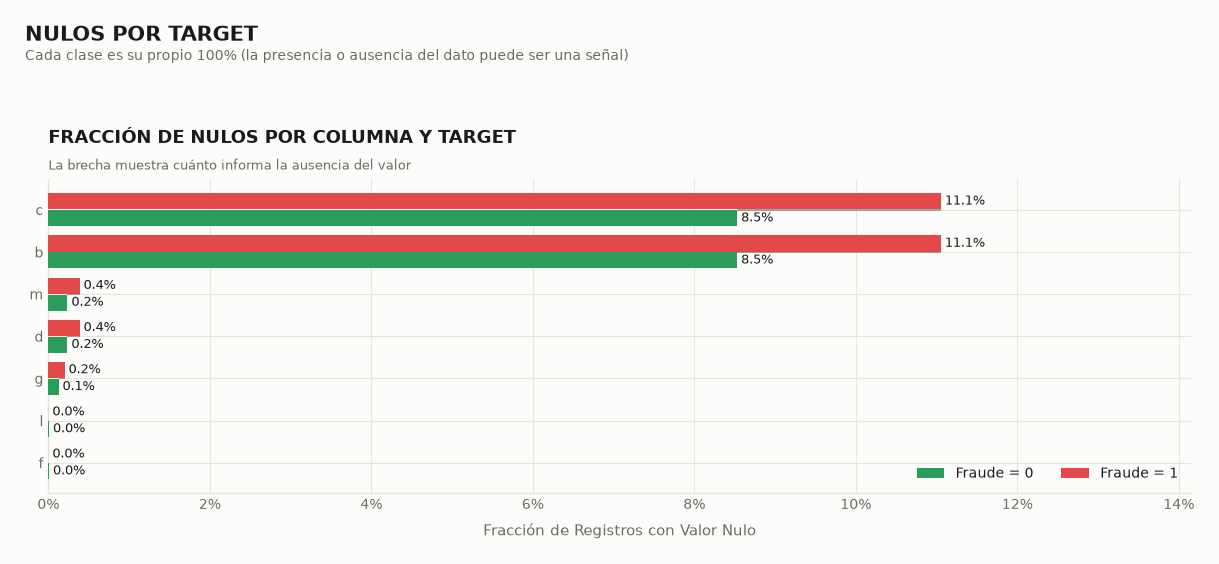

In [10]:
null_by_target = (
    raw_df[feature_cols].isna()
    .groupby(raw_df['fraude'])
    .mean()
    .reindex([0, 1])
)
null_table = null_by_target.T.rename(columns = {0: 'Fraude = 0', 1: 'Fraude = 1'})
null_table['BrechaAbsoluta'] = (null_by_target.loc[1] - null_by_target.loc[0]).abs()
display_table(
    null_table.sort_values('BrechaAbsoluta', ascending = False),
    caption = 'FRACCIÓN DE NULOS POR VARIABLE Y TARGET',
    formats = {column: '{:.2%}' for column in null_table.columns},
)

plot_df = null_by_target.T.loc[(null_by_target.T > 0).any(axis=1)].copy()
plot_df['gap'] = (plot_df[1] - plot_df[0]).abs()
plot_df = plot_df.sort_values('gap')
y_values = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(12, max(4.5, 0.48 * len(plot_df) + 2)))
ax.hlines(y_values, plot_df[0], plot_df[1], color = COLOR_MUTED , linewidth=1.3, alpha=0.65, zorder=2)
ax.barh(y_values - 0.20, plot_df[0], 0.38 , color = COLOR_NORMAL, label = 'Fraude = 0', zorder = 3)
ax.barh(y_values + 0.20, plot_df[1], 0.38 , color = COLOR_FRAUD , label = 'Fraude = 1', zorder = 3)
for y_value, (normal_rate, fraud_rate) in zip(
    y_values, plot_df[[0, 1]].to_numpy()
):
    ax.text(normal_rate, y_value - 0.20, f' {normal_rate:.1%}', va='center', fontsize=9)
    ax.text(fraud_rate, y_value + 0.20 , f' {fraud_rate:.1%}' , va='center', fontsize=9)
ax.set_yticks(y_values, plot_df.index)
ax.xaxis.set_major_formatter(PCT)
ax.set_xlim(0, max(plot_df[[0, 1]].max().max() * 1.28, 0.01))
ax.legend(loc = 'lower right', ncol=2)
finish_ax(
    ax,
    title    = 'FRACCIÓN DE NULOS POR COLUMNA Y TARGET',
    subtitle = 'La brecha muestra cuánto informa la ausencia del valor',
    xlabel   = 'Fracción de Registros con Valor Nulo',
    grid     = 'x',
)
finish_figure(
    fig, 'NULOS POR TARGET',
    'Cada clase es su propio 100% (la presencia o ausencia del dato puede ser una señal)',
    '2_1_NULOSxTARGET.png'
)

In [11]:
tbl = null_by_target.copy()
tbl.index = ['Fraude = 0', 'Fraude = 1']
tbl.loc['Δ  ·  Brecha |f1-f0|'] = (null_by_target.loc[1] - null_by_target.loc[0]).abs()

order = tbl.loc['Δ  ·  Brecha |f1-f0|'].sort_values(ascending = False).index
tbl   = tbl[order]
tbl.index.name = 'Clase'

top_var = order[0]
def highlight_top(col):
    is_top = col.name == top_var
    return ['box-shadow: inset 4px 0 0 #C9622E, inset -1px 0 0 rgba(201,98,46,0.3);'
            if is_top else '' for _ in col]
styled = (
    tbl.style
       .format('{:.2%}')
       .format_index(format_class_name, axis=0, escape=None)
       .apply(spectral_bar , axis = None)
       .apply(highlight_top, axis = 0)
       .set_table_styles(styles)
       .set_caption('FRACCIÓN DE NULOS POR VARIABLE, SEGMENTADA POR TARGET · Δ = Cuánto delata el Nulo')
)
styled

,c,b,d,m,g,f,l,a,o,monto,fecha,p,k,n,j,h,e,score
Clase,,,,,,,,,,,,,,,,,,
Fraude = 0,8.53%,8.53%,0.24%,0.24%,0.13%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Fraude = 1,11.05%,11.05%,0.39%,0.39%,0.20%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Δ Brecha |f1-f0|,2.52%,2.52%,0.15%,0.15%,0.07%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


___
### 🔢 *2.2 Cardinalidad*

,Valores Únicos
k,150000
fecha,145813
c,135090
e,43208
monto,17831
j,8324
b,7672
l,7297
m,1793
f,1338


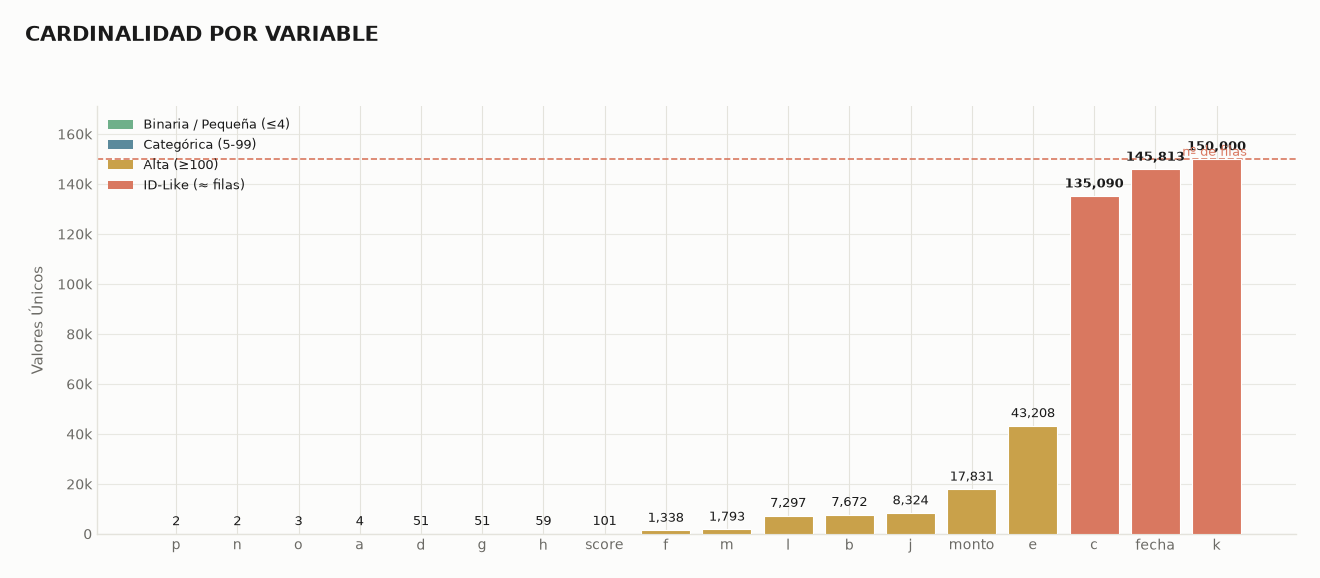

In [12]:
cardinality = raw_df[feature_cols].nunique(dropna = True).sort_values()
n_rows = len(raw_df)

def cardinality_color(value):
    if value >= 0.9 * n_rows:
        return COLORS['id_like']
    if value >= 100:
        return COLORS['high_cardinality']
    if value > 4:
        return COLOR_TEAL
    return COLORS['small_category']
display_table(
    cardinality.sort_values(ascending=False).to_frame('Valores Únicos'),
    caption = 'CARDINALIDAD DE LAS VARIABLES'
)

fig, ax = plt.subplots(figsize=(13, 5.5))
x_values = np.arange(len(cardinality))
ax.bar(x_values, cardinality.values,
       color=[cardinality_color(value) for value in cardinality.values],
       edgecolor='white', linewidth=0.8, zorder=3)
for x_value, value in zip(x_values, cardinality.values):
    ax.text(x_value, value + n_rows * 0.015, f'{value:,}',
            ha='center', va='bottom', fontsize=9,
            weight='bold' if value >= 0.9 * n_rows else 'normal')
ax.axhline(n_rows, color=COLORS['id_like'], linestyle='--', linewidth=1.2)
ax.text(len(cardinality) - 0.5, n_rows, ' nº de filas',
        color=COLORS['id_like'], ha='right', va='bottom', fontsize=9)
ax.set_xticks(x_values, cardinality.index)
ax.set_ylim(0, n_rows * 1.14)
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda value, _: f'{value:,.0f}' if value < 1000 else f'{value / 1000:.0f}k'
))
legend = [
    Patch(facecolor = COLORS['small_category']  , label = 'Binaria / Pequeña (≤4)'),
    Patch(facecolor = COLOR_TEAL                , label = 'Categórica (5-99)'),
    Patch(facecolor = COLORS['high_cardinality'], label = 'Alta (≥100)'),
    Patch(facecolor = COLORS['id_like']         , label = 'ID-Like (≈ filas)'),
]
ax.legend(handles = legend, loc = 'upper left', fontsize = 9)
finish_ax(ax, title = None, ylabel = 'Valores Únicos', grid = 'y')
finish_figure(fig, 'CARDINALIDAD POR VARIABLE', '', '2_2_CARDINALIDAD.png')

___
### 🧾 2.3 *Duplicados Exactos*


In [13]:
duplicate_count     = int(raw_df[feature_cols + ['fraude']].duplicated().sum())
entity_counts       = raw_df['j'].value_counts()
cutoff              = raw_df['_fecha_dt'].max() - pd.Timedelta(days=14)
train_entities      = set(raw_df.loc[raw_df['_fecha_dt'] < cutoff, 'j'])
evaluation_entities = raw_df.loc[raw_df['_fecha_dt'] >= cutoff, 'j']
print(
    f'   ├─ Duplicados Exactos           : {duplicate_count:,} de {len(raw_df):,}\n'
    f'   ├─ Entidades Totales en j       : {len(entity_counts):,}\n'
    f'   ├─ Entidades con una Sola Fila  : {(entity_counts == 1).sum():,}\n'
    f'   └─ Val/Test con Entidad no Vista: {(~evaluation_entities.isin(train_entities)).mean():.2%}'
)

   ├─ Duplicados Exactos           : 0 de 150,000
   ├─ Entidades Totales en j       : 8,324
   ├─ Entidades con una Sola Fila  : 2,258
   └─ Val/Test con Entidad no Vista: 2.23%


___
___
## **📊 3. Distribuciones, Categorías y Outliers**

> - En **3.1 Distribuciones Numéricas**, `c` y `monto` muestran colas derechas que justifican la vista logarítmica; `score` está acotado entre 0 y 100; `k` ocupa todo el intervalo **[0, 1]** y no exhibe una forma de identificador en la distribución.
> - En **3.2 Distribuciones por Fraude**, `score` separa visualmente las clases en los valores altos y `monto` muestra una diferencia más moderada. Las curvas de `k` son muy parecidas entre fraude y no fraude, por lo que su alta cardinalidad no debe confundirse con señal.
> - En **3.3 Categoría `g`**, el volumen se concentra en `BR` (**111.628**) y `AR` (**31.964**); las categorías pequeñas presentan tasas inestables y deben interpretarse junto con su soporte mediante `rare_category`.
> - En **3.4 Outliers**, `monto` tiene el mayor lift del grupo extremo (**8,91%**, **1,78×** la prevalencia), seguido por `b` y `c`. `k` no produce outliers con la regla IQR porque está acotada, lo que es compatible con tratarla como numérica continua.

___
### 📈 *3.1 Distribuciones de las Variables Numéricas*

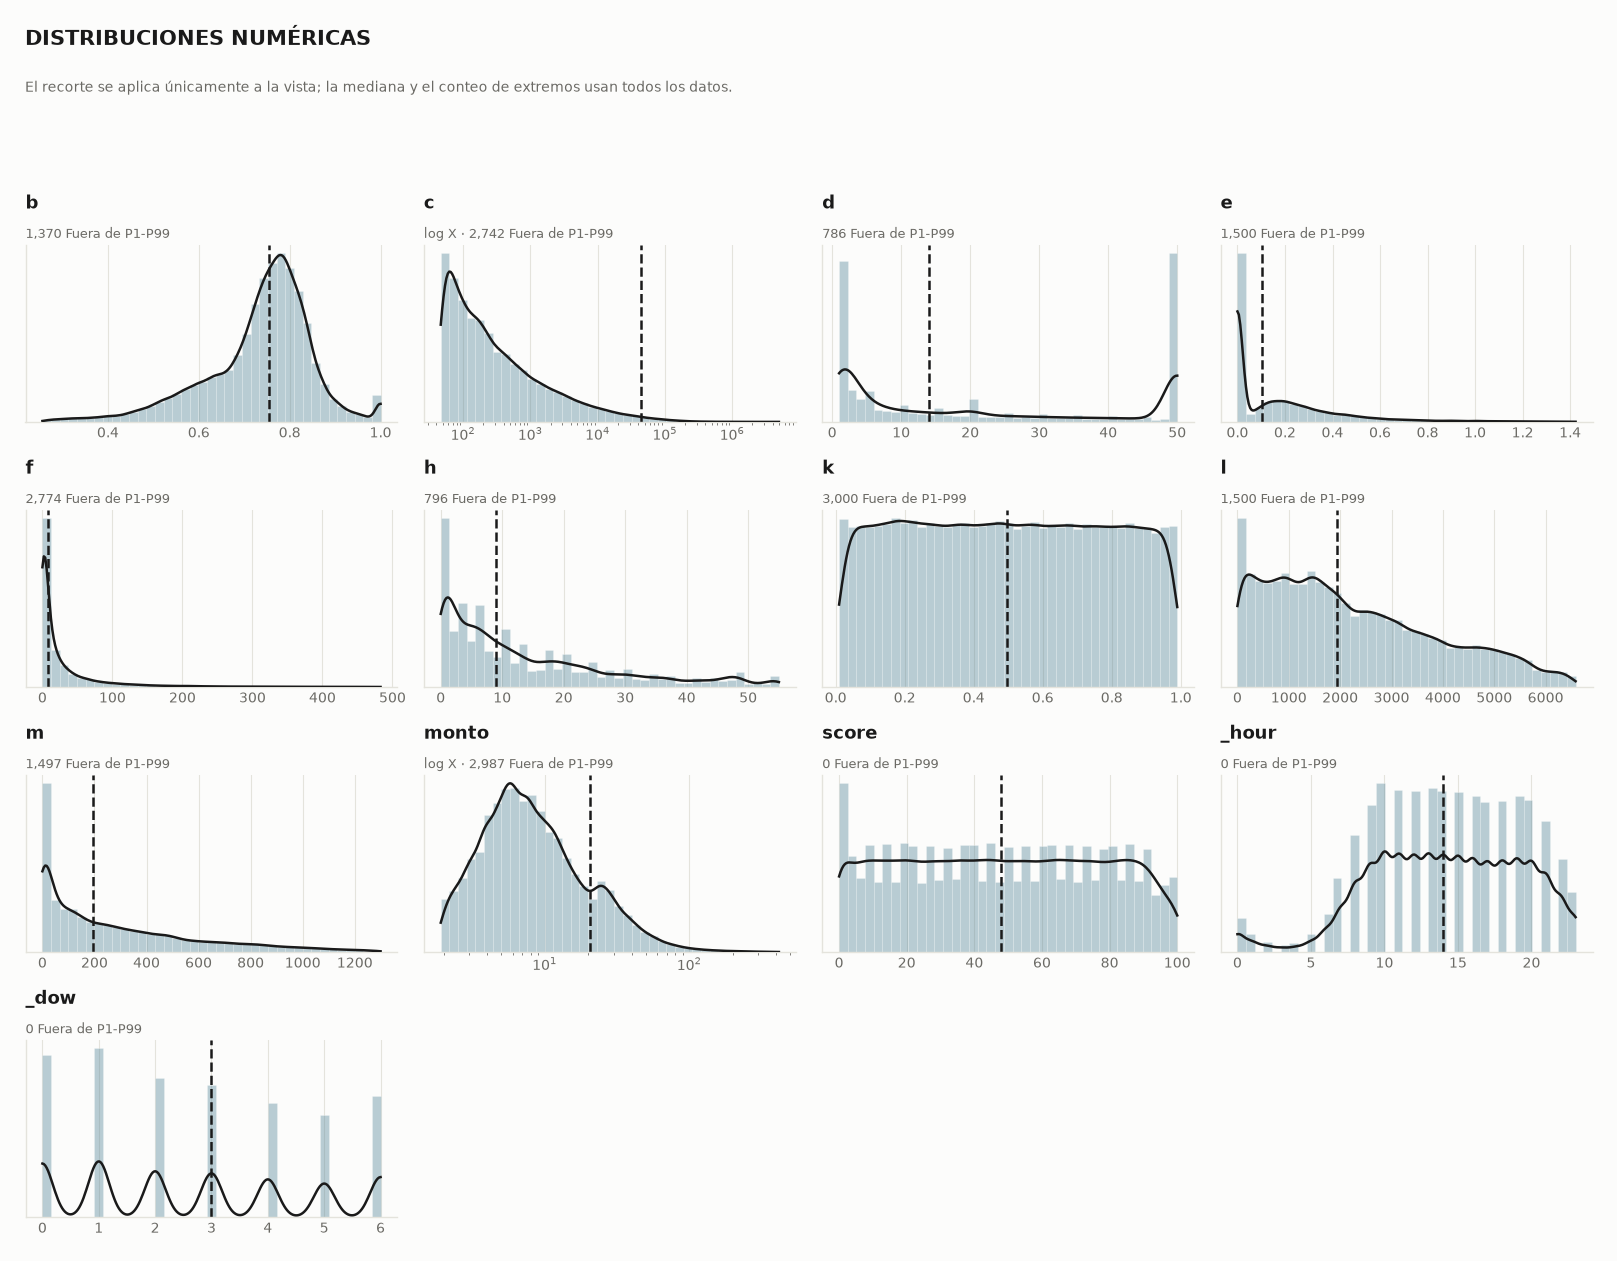

In [14]:
n_columns   = 4
n_rows_plot = int(np.ceil(len(numerical_cols) / n_columns))
fig, axes   = plt.subplots(
    n_rows_plot, n_columns,
    figsize = (4.0 * n_columns, 3.1 * n_rows_plot),
    squeeze = False,
)
axes = axes.ravel()

for ax, column in zip(axes, numerical_cols):
    series    = raw_df[column].dropna()
    low, high = series.quantile([0.01, 0.99])
    visible   = series[(series >= low) & (series <= high)]
    use_log   = wants_log(series)
    color     = COLOR_TEAL

    if use_log:
        visible = visible[visible > 0]
        edges   = np.logspace(np.log10(visible.min()), np.log10(visible.max()), 40)
        x_grid  = np.logspace(np.log10(visible.min()), np.log10(visible.max()), 240)
        ax.set_xscale('log')
        density = gaussian_kde(np.log10(visible))(np.log10(x_grid))
        density = density / (x_grid * np.log(10))
    else:
        edges   = np.linspace(visible.min(), visible.max(), 40)
        x_grid  = np.linspace(visible.min(), visible.max(), 240)
        density = gaussian_kde(visible)(x_grid)

    ax.hist(visible, bins = edges, density = True, color = color, alpha = 0.42, edgecolor = 'white', linewidth = 0.4, zorder = 2)
    ax.plot(x_grid, density   , color = COLORS['ink'], linewidth = 1.8 , zorder = 3)
    ax.axvline(series.median(), color = COLORS['ink'], linestyle = '--', linewidth = 1.8)
    removed = len(series) - len(visible)
    subtitle = f'log X · {removed:,} Fuera de P1-P99' if use_log else f'{removed:,} Fuera de P1-P99'
    finish_ax(ax, title=column, subtitle=subtitle, grid='y')
    ax.set_yticks([])

for ax in axes[len(numerical_cols):]:
    ax.axis('off')
finish_figure(
    fig, 'DISTRIBUCIONES NUMÉRICAS',
    'El recorte se aplica únicamente a la vista; la mediana y el conteo de extremos usan todos los datos.',
    '3_1_DISTRIBUCIONES_NUMERICAS.png'
)

___
### 🧬 *3.2 Distribuciones Separadas por Fraude*

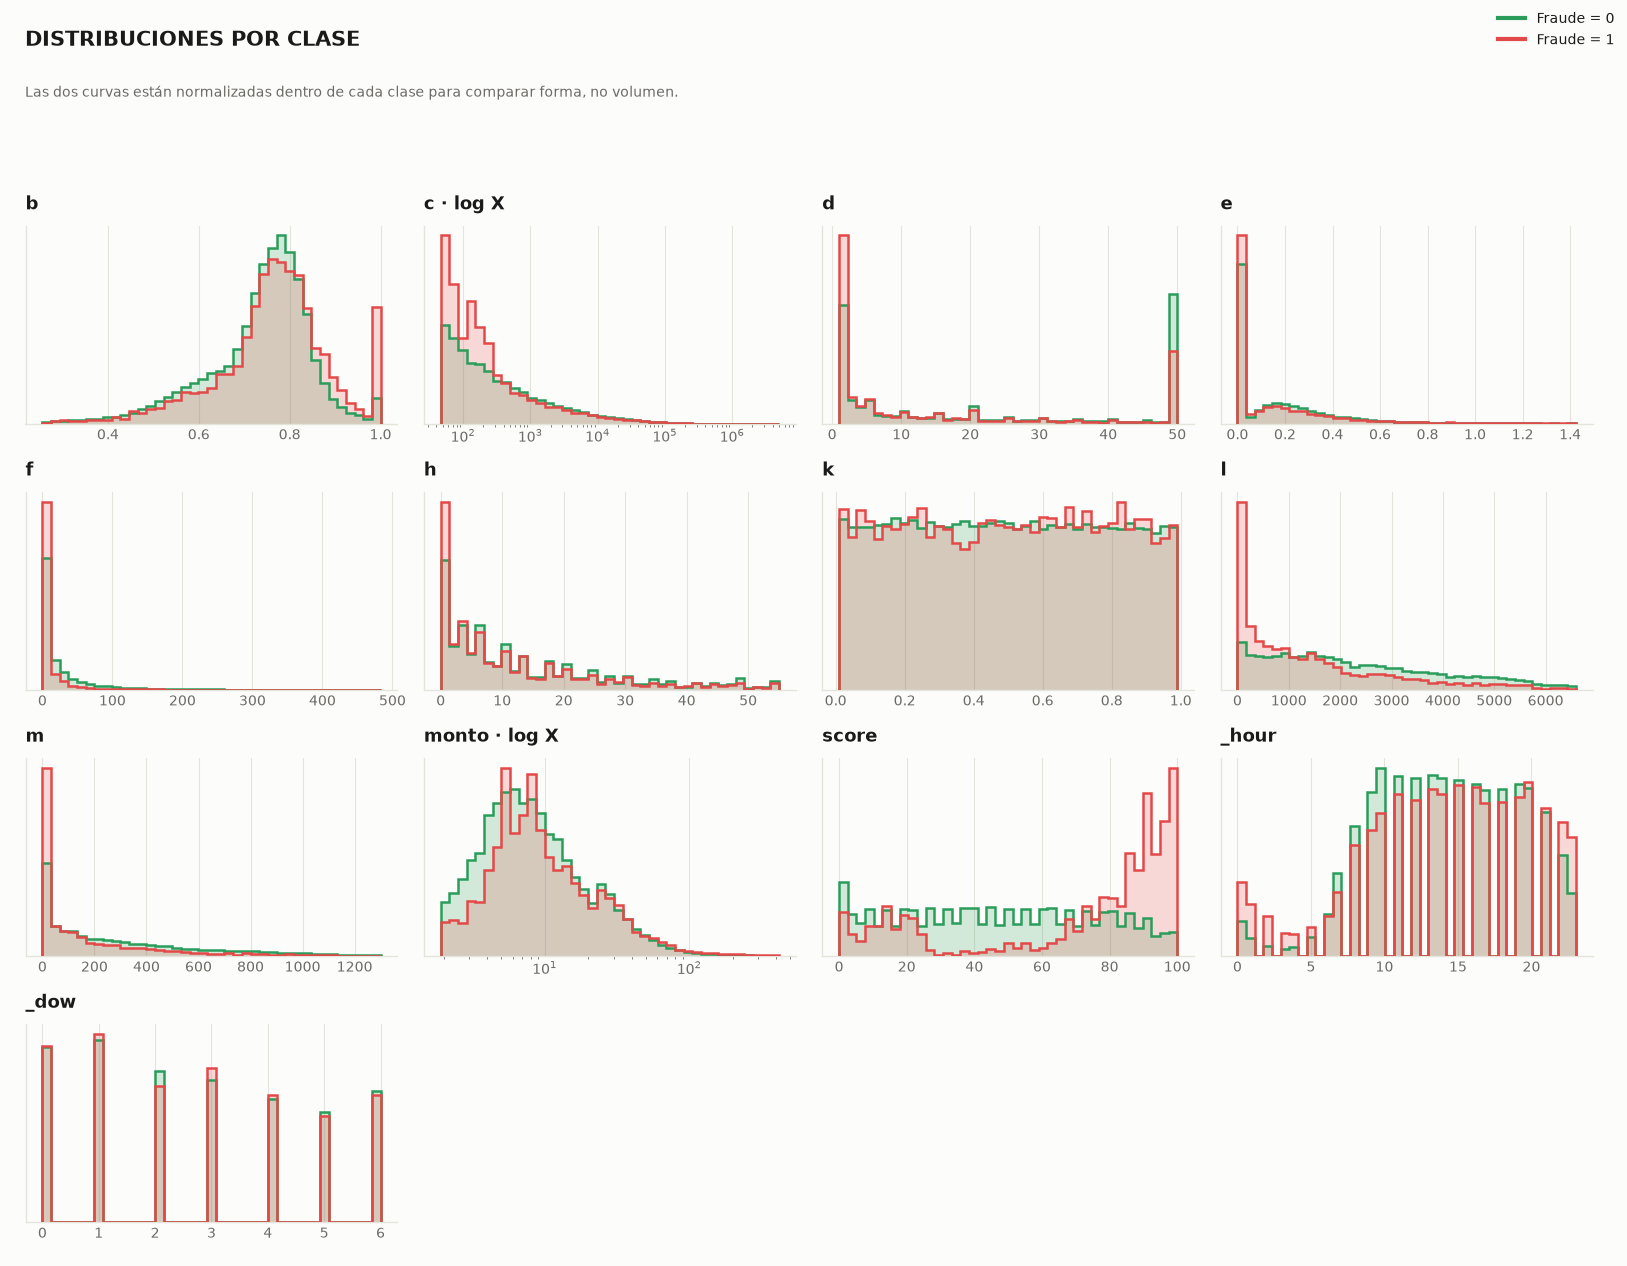

In [15]:
fig, axes = plt.subplots(
    n_rows_plot, n_columns,
    figsize = (4.0 * n_columns, 3.1 * n_rows_plot),
    squeeze = False,
)
axes = axes.ravel()

for ax, column in zip(axes, numerical_cols):
    full = raw_df[column].dropna()
    low, high = full.quantile([0.01, 0.99])
    use_log = wants_log(full)
    normal  = raw_df.loc[raw_df['fraude'] == 0, column].dropna()
    fraud   = raw_df.loc[raw_df['fraude'] == 1, column].dropna()
    normal  = normal[(normal >= low) & (normal <= high)]
    fraud   = fraud[(fraud >= low) & (fraud <= high)]

    if use_log:
        normal, fraud = normal[normal > 0], fraud[fraud > 0]
        edges = np.logspace(
            np.log10(max(low, full[full > 0].min())),
            np.log10(high), 40
        )
        ax.set_xscale('log')
    else:
        edges = np.linspace(low, high, 40)

    for series, color, label in [
        (normal, COLOR_NORMAL, 'Fraude = 0'),
        (fraud , COLOR_FRAUD , 'Fraude = 1'),
    ]:
        ax.hist(series, bins=edges, density=True, color=color,
                alpha=0.20, zorder=2)
        ax.hist(series, bins=edges, density=True, histtype='step',
                color=color, linewidth=1.8, label=label, zorder=3)
    finish_ax(ax, title=f"{column}{' · log X' if use_log else ''}", grid='y')
    ax.set_yticks([])

for ax in axes[len(numerical_cols):]:
    ax.axis('off')

legend = [
    Line2D([0], [0], color=COLOR_NORMAL, linewidth=3, label = 'Fraude = 0'),
    Line2D([0], [0], color=COLOR_FRAUD , linewidth=3, label = 'Fraude = 1'),
]
fig.legend(handles = legend, loc = 'upper right')
finish_figure(
    fig, 'DISTRIBUCIONES POR CLASE',
    'Las dos curvas están normalizadas dentro de cada clase para comparar forma, no volumen.',
    '3_2_DISTRIBUCIONES_POR_CLASE.png'
)

___
### 🌎 *3.3 Categoría `g`: Volumen y Riesgo*

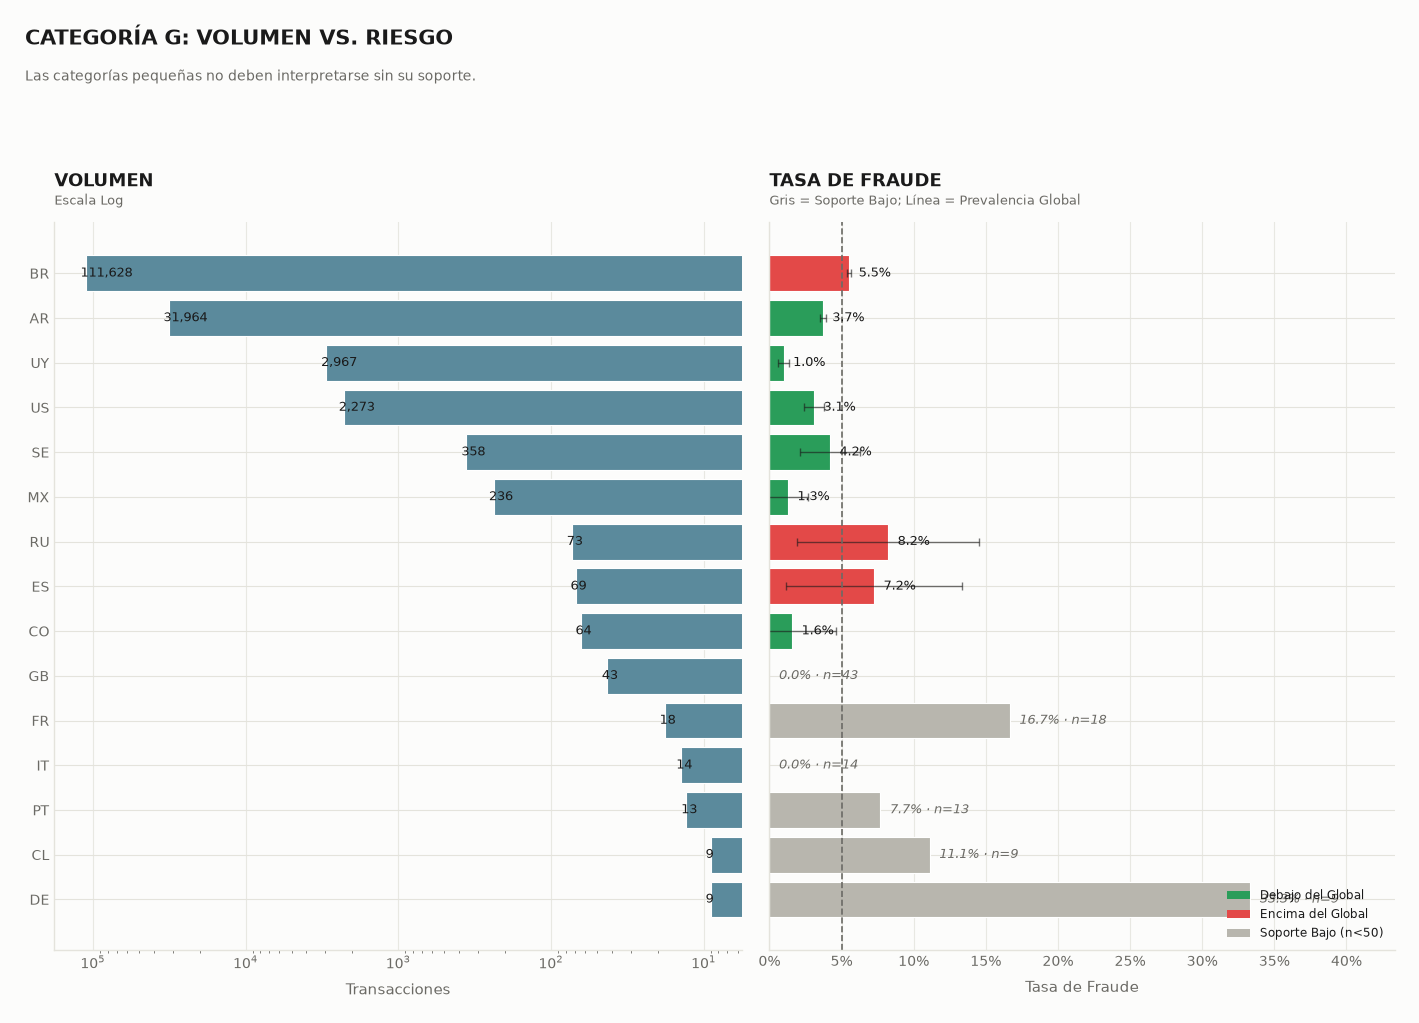

In [16]:
TOPN        = 15
MIN_SUPPORT = 50
g_counts = raw_df['g'].value_counts()
g_rates = raw_df.groupby('g', observed=True)['fraude'].mean()
g_sizes = raw_df.groupby('g', observed=True)['fraude'].size()
categories = g_counts.head(TOPN).sort_values().index
volumes  = g_counts.loc[categories].to_numpy()
rates    = g_rates.loc[categories].to_numpy()
sizes    = g_sizes.loc[categories].to_numpy()
y_values = np.arange(len(categories))
support_ok = sizes >= MIN_SUPPORT
risk_bar_colors = [
    COLOR_GRAY if not ok else (
        COLOR_FRAUD if rate > BASE_PREVALENCE else COLOR_NORMAL
    )
    for rate, ok in zip(rates, support_ok)
]

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(14, 0.52 * len(categories) + 2.2),
    sharey=True, gridspec_kw={'width_ratios': [1.1, 1]},
)
ax_left.barh(y_values, volumes, color=COLOR_TEAL, edgecolor='white', linewidth=0.8)
for y_value, volume in zip(y_values, volumes):
    ax_left.text(volume * 1.08, y_value, f'{volume:,}', va='center', fontsize=9)
ax_left.set_xscale('log')
ax_left.invert_xaxis()
ax_left.set_yticks(y_values, categories)
finish_ax(ax_left, title = 'VOLUMEN', subtitle = 'Escala Log', xlabel = 'Transacciones', grid = 'x')

ax_right.barh(y_values, rates, color=risk_bar_colors, edgecolor='white', linewidth=0.8)
ax_right.errorbar(
    rates[support_ok], y_values[support_ok],
    xerr=1.96 * np.sqrt(rates[support_ok] * (1 - rates[support_ok])
                        / sizes[support_ok]),
    fmt='none', ecolor=COLORS['ink'], elinewidth=1, capsize=3, alpha=0.6,
)
ax_right.axvline(BASE_PREVALENCE, color=COLOR_MUTED, linestyle='--', linewidth=1.2)
for y_value, rate, size, ok in zip(y_values, rates, sizes, support_ok):
    ax_right.text(
        rate + max(rates.max(), BASE_PREVALENCE) * 0.02,
        y_value, f'{rate:.1%}' + ('' if ok else f' · n={size}'),
        va='center', fontsize=9, color=COLORS['ink'] if ok else COLOR_MUTED,
        style='normal' if ok else 'italic',
    )
ax_right.xaxis.set_major_formatter(PCT)
ax_right.set_xlim(0, max(rates.max(), 2 * BASE_PREVALENCE) * 1.3)
finish_ax(ax_right, title = 'TASA DE FRAUDE', subtitle = 'Gris = Soporte Bajo; Línea = Prevalencia Global', xlabel = 'Tasa de Fraude', grid = 'x')
ax_right.legend(handles=[
    Patch(facecolor = COLOR_NORMAL, label = 'Debajo del Global'),
    Patch(facecolor = COLOR_FRAUD , label = 'Encima del Global'),
    Patch(facecolor = COLOR_GRAY  , label = f'Soporte Bajo (n<{MIN_SUPPORT})'),
], loc = 'lower right', fontsize = 8.5)

finish_figure(
    fig, 'CATEGORÍA G: VOLUMEN VS. RIESGO',
    'Las categorías pequeñas no deben interpretarse sin su soporte.',
    '3_3_CATEGORIA_G.png'
)

___
### 🧯 *3.4 Outliers*


,Fracción Moderados,Fracción Extremos,n Moderados,Tasa Fraude Outlier,Lift
Feature,,,,,
monto,9.88%,6.08%,14823,8.91%,1.78x
b,6.24%,1.26%,8554,8.15%,1.63x
c,12.37%,8.74%,16946,6.66%,1.33x
e,5.05%,1.83%,7580,5.09%,1.02x
h,3.36%,0.00%,5045,3.85%,0.77x
m,3.01%,0.12%,4499,1.82%,0.36x
f,11.41%,6.69%,17116,1.79%,0.36x
l,0.26%,0.00%,384,1.56%,0.31x
d,0.00%,0.00%,0,nan%,nanx


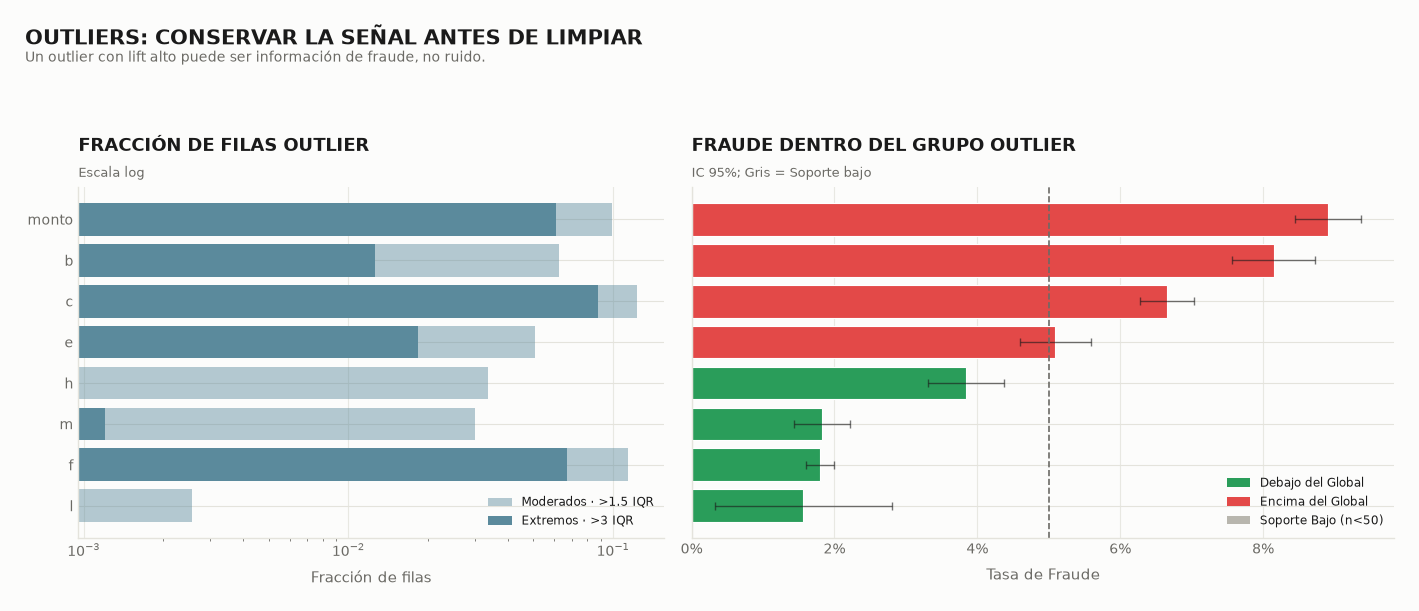

In [17]:
outlier_rows = []
for column in numerical_cols:
    series = raw_df[column].dropna()
    moderate = outlier_mask(series, 1.5)
    extreme  = outlier_mask(series, 3.0)
    indexes  = series[moderate].index
    outlier_rate = raw_df.loc[indexes, 'fraude'].mean() if len(indexes) else np.nan
    outlier_rows.append({
        'Feature'            : column,
        'Fracción Moderados' : moderate.mean(),
        'Fracción Extremos'  : extreme.mean(),
        'n Moderados'        : int(moderate.sum()),
        'Tasa Fraude Outlier': outlier_rate,
    })

outlier_table = pd.DataFrame(outlier_rows).set_index('Feature')
outlier_table['Lift'] = outlier_table['Tasa Fraude Outlier'] / BASE_PREVALENCE
display_table(
    outlier_table.sort_values('Lift', ascending=False),
    caption='Cercas de Tukey por Feature',
    formats={
        'Fracción Moderados' : '{:.2%}',
        'Fracción Extremos'  : '{:.2%}',
        'Tasa Fraude Outlier': '{:.2%}',
        'Lift'               : '{:.2f}x',
    },
)

plot_outliers = outlier_table[outlier_table['n Moderados'] > 0].sort_values('Tasa Fraude Outlier')
y_values = np.arange(len(plot_outliers))
reliable = plot_outliers['n Moderados'] >= MIN_SUPPORT

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(14, max(4.5, 0.48 * len(plot_outliers) + 2)),
    sharey=True, gridspec_kw={'width_ratios': [1, 1.2]},
)
ax_left.barh(y_values, plot_outliers['Fracción Moderados'], color=COLOR_TEAL, alpha=0.45, label='Moderados · >1.5 IQR')
ax_left.barh(y_values, plot_outliers['Fracción Extremos'] , color=COLOR_TEAL, label='Extremos · >3 IQR')
ax_left.set_xscale('log')
ax_left.set_yticks(y_values, plot_outliers.index)
finish_ax(ax_left, title='FRACCIÓN DE FILAS OUTLIER', subtitle='Escala log', xlabel='Fracción de filas', grid='x')
ax_left.legend(loc = 'lower right', fontsize = 8.5)

colors = [
    COLOR_GRAY if not ok else (
        COLOR_FRAUD if rate > BASE_PREVALENCE else COLOR_NORMAL
    )
    for rate, ok in zip(plot_outliers['Tasa Fraude Outlier'], reliable)
]
ax_right.barh(y_values, plot_outliers['Tasa Fraude Outlier'], color=colors, edgecolor='white', linewidth=0.8)
se = np.sqrt(
    plot_outliers['Tasa Fraude Outlier']
    * (1 - plot_outliers['Tasa Fraude Outlier'])
    / plot_outliers['n Moderados'].clip(lower=1)
)
ax_right.errorbar(
    plot_outliers.loc[reliable, 'Tasa Fraude Outlier'],
    y_values[reliable.to_numpy()],
    xerr=1.96 * se.loc[reliable],
    fmt='none', ecolor=COLORS['ink'], elinewidth=1, capsize=3, alpha=0.6,
)
ax_right.axvline(BASE_PREVALENCE, color=COLOR_MUTED, linestyle='--', linewidth=1.2)
ax_right.xaxis.set_major_formatter(PCT)
finish_ax(ax_right, title='FRAUDE DENTRO DEL GRUPO OUTLIER', subtitle='IC 95%; Gris = Soporte bajo', xlabel='Tasa de Fraude', grid='x')
ax_right.legend(handles=[
    Patch(facecolor = COLOR_NORMAL, label = 'Debajo del Global'),
    Patch(facecolor = COLOR_FRAUD , label = 'Encima del Global'),
    Patch(facecolor = COLOR_GRAY  , label = f'Soporte Bajo (n<{MIN_SUPPORT})'),
], loc = 'lower right', fontsize = 8.5)

finish_figure(
    fig, 'OUTLIERS: CONSERVAR LA SEÑAL ANTES DE LIMPIAR',
    'Un outlier con lift alto puede ser información de fraude, no ruido.',
    '3_4_OUTLIERS.PNG'
)

___
___
## **🎯 4. Señal Univariada, Interacciones y Calendario**

> - En **4.1 Tasas por Decil y Categoría**, `monto` pasa de **3,1%** en el primer decil a **8,9%** en el décimo. `score` tiene una forma claramente no monotónica: cae hasta aproximadamente **0,3%–1,3%** en deciles medios y sube a **21,8%** en el décimo. Por categorías, destacan `o = N` (**21,75%**), `n = False` (**16,11%**) y `a = 1` (**9,42%**); el estado missing de `o` queda en **2,05%**.
> - En **4.2 Interacciones**, `n`, `o`, `p` y `a` separan las curvas de `monto` y `score`; las divergencias crecen en los deciles altos y sugieren efectos aditivos e interacciones que deben validarse en modelos. Los grupos pequeños deben mantenerse con sus intervalos y soporte.
> - En **4.3 Calendario**, la señal horaria es más marcada que la semanal: la hora **02** alcanza **17,2%** y la hora **10** cae a **3,8%**; por día, el gráfico muestra fluctuaciones más estrechas alrededor de la prevalencia global. Las bandas de confianza son necesarias para no sobrerreaccionar a días con menor soporte.
> - En **4.4 PR-AUC**, `score` lidera con **0,1765** (**3,5×** la base), seguido por `b` (**0,0758**) y `monto` (**0,0729**). `k` obtiene **0,0503**, prácticamente la prevalencia **0,0500**; se incluye como numérica por su naturaleza, aunque no muestra señal univariada apreciable.

___
### 📏 *4.1 Tasas por Decil y Categoría*

,mean,count
bin,,
"(0.019, 5.35]",3.12%,"15,005"
"(5.35, 7.83]",4.92%,"15,027"
"(7.83, 10.91]",4.57%,"14,986"
"(10.91, 14.76]",3.97%,"15,050"
"(14.76, 20.61]",4.66%,"14,942"
"(20.61, 26.84]",4.41%,"14,993"
"(26.84, 35.083]",5.11%,"14,997"
"(35.083, 48.95]",4.63%,"15,001"
"(48.95, 86.652]",5.73%,"14,999"


,mean,count
bin,,
"(-0.001, 8.0]",2.78%,"15,807"
"(8.0, 18.0]",4.71%,"14,996"
"(18.0, 28.0]",3.06%,"14,950"
"(28.0, 38.0]",0.33%,"14,998"
"(38.0, 48.0]",0.63%,"15,093"
"(48.0, 58.0]",1.31%,"14,935"
"(58.0, 68.0]",2.14%,"15,018"
"(68.0, 78.0]",5.32%,"14,910"
"(78.0, 88.0]",8.89%,"15,065"


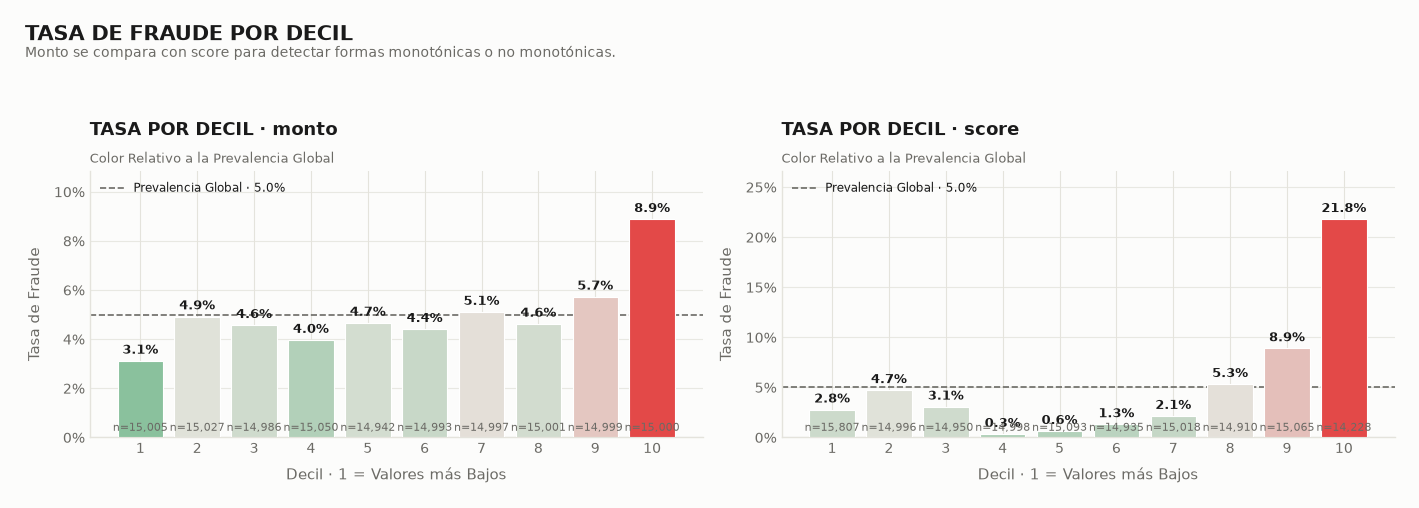

,mean,count
a,,
1,9.42%,"4,195"
3,9.06%,"2,848"
2,7.78%,"14,378"
4,4.46%,"128,579"


,mean,count
n,,
False,16.11%,"14,647"
True,3.80%,"135,353"


,mean,count
o,,
N,21.75%,"17,052"
Y,6.45%,"24,091"
missing,2.05%,"108,857"


,mean,count
p,,
N,7.60%,"66,871"
Y,2.91%,"83,129"


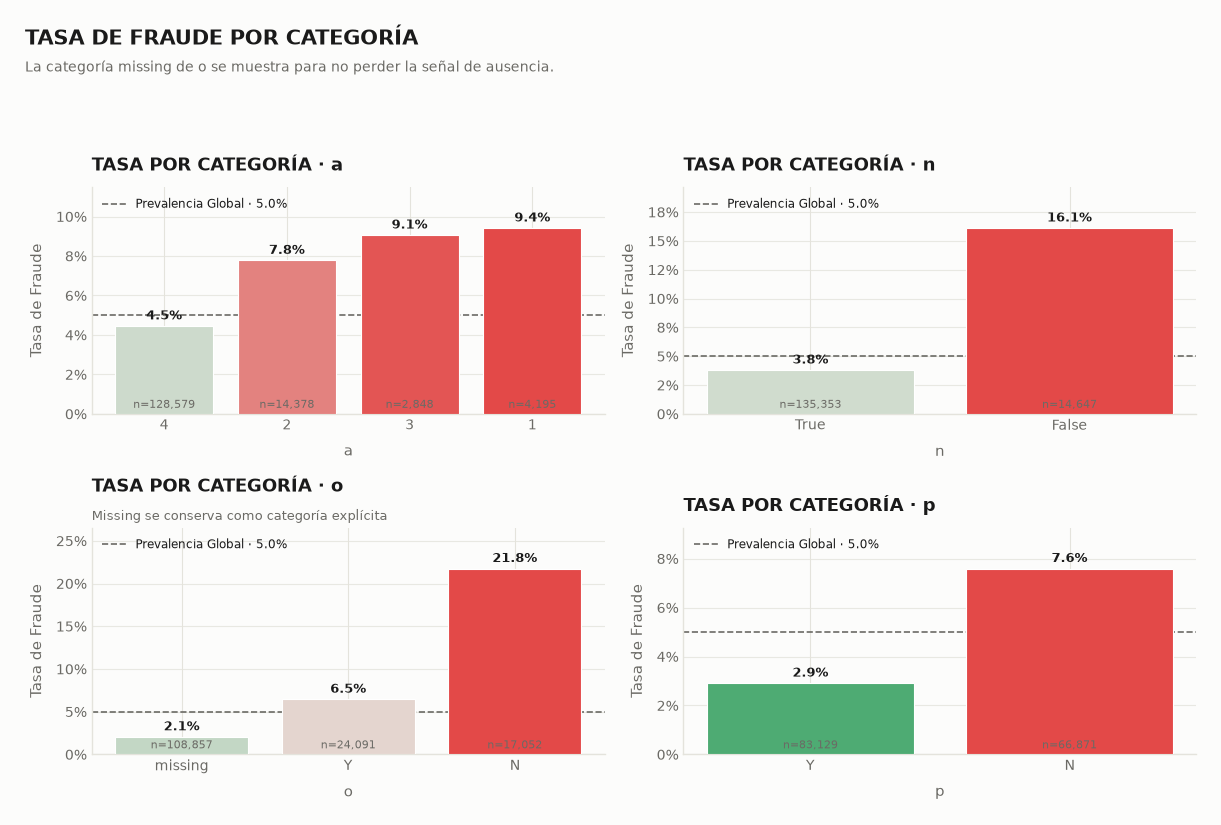

In [18]:
rate_tables = {
    column: fraud_rate_by_bin(raw_df, column)
    for column in ['monto', 'score']
}
for column, table in rate_tables.items():
    display_table(
        table,
        caption = f'TASA DE FRAUDE POR DECIL · {column}',
        formats = {'mean': '{:.2%}', 'count': '{:,.0f}'},
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (column, table) in zip(axes, rate_tables.items()):
    plot_rate_bars(
        ax,
        [str(index + 1) for index in range(len(table))],
        table['mean'].to_numpy(),
        table['count'].to_numpy(),
        title    = f'TASA POR DECIL · {column}',
        subtitle = 'Color Relativo a la Prevalencia Global',
        xlabel   = 'Decil · 1 = Valores más Bajos',
    )
finish_figure(
    fig, 'TASA DE FRAUDE POR DECIL',
    'Monto se compara con score para detectar formas monotónicas o no monotónicas.',
    '4_1_TASA_MONTO_SCORE.png'
)

category_frame          = raw_df.copy()
categorical_cols_sin_jg = [i for i in categorical_cols if i not in {'j', 'g'}]
category_rate_tables    = {}
for column in categorical_cols_sin_jg:
    table = (
        category_frame.groupby(column, observed=True)['fraude']
        .agg(mean='mean', count='count')
        .sort_values('mean', ascending=False)
    )
    category_rate_tables[column] = table
    display_table(
        table,
        caption = f'TASA DE FRAUDE POR CATEGORÍA · {column}',
        formats = {'mean': '{:.2%}', 'count': '{:,.0f}'}
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.flatten(), categorical_cols_sin_jg):
    table = category_rate_tables[column].sort_values('mean')
    plot_rate_bars(
        ax, table.index.astype(str), table['mean'], table['count'],
        title    = f'TASA POR CATEGORÍA · {column}',
        subtitle = 'Missing se conserva como categoría explícita' if column == 'o' else None,
        xlabel   = column
    )
finish_figure(
    fig, 'TASA DE FRAUDE POR CATEGORÍA',
    'La categoría missing de o se muestra para no perder la señal de ausencia.',
    '4_1_TASA_CATEGORIAS.png'
)

___
### 🔀 *4.2 Interacción Categóricas con `Monto` y `Score`*

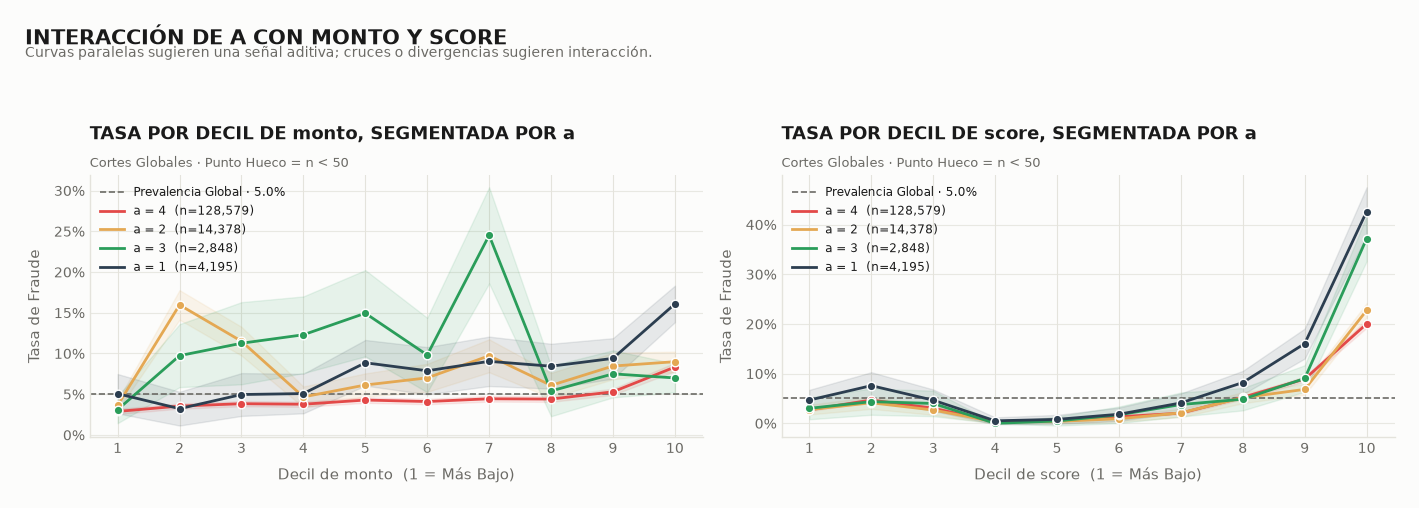

,mean,count
a,,
1,9.42%,"4,195"
3,9.06%,"2,848"
2,7.78%,"14,378"
4,4.46%,"128,579"


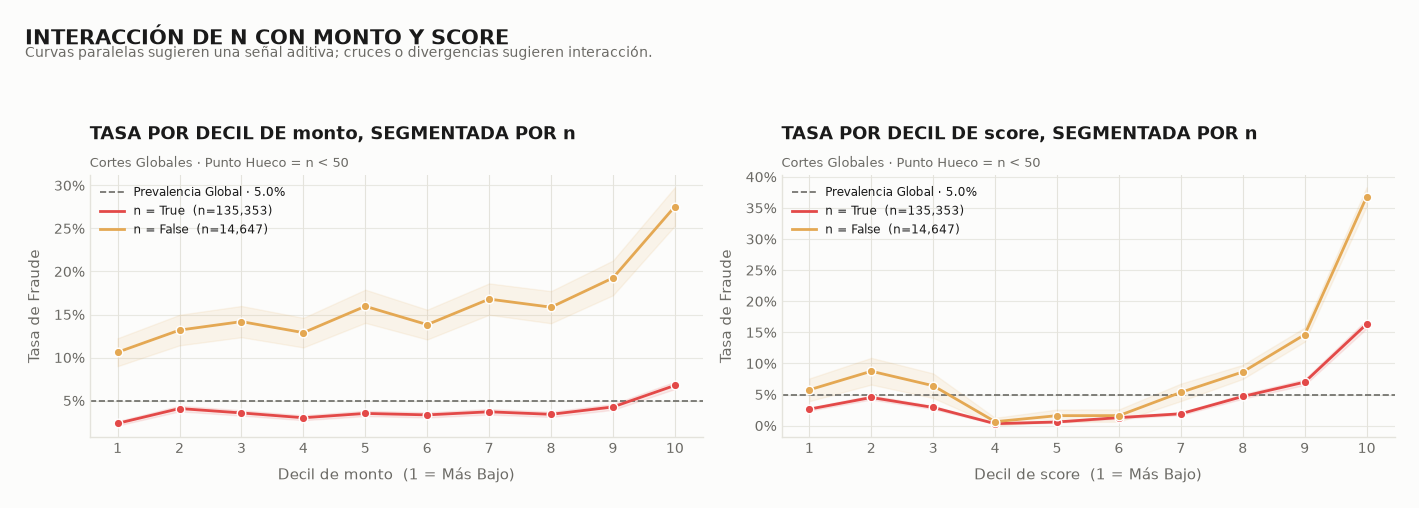

,mean,count
n,,
False,16.11%,"14,647"
True,3.80%,"135,353"


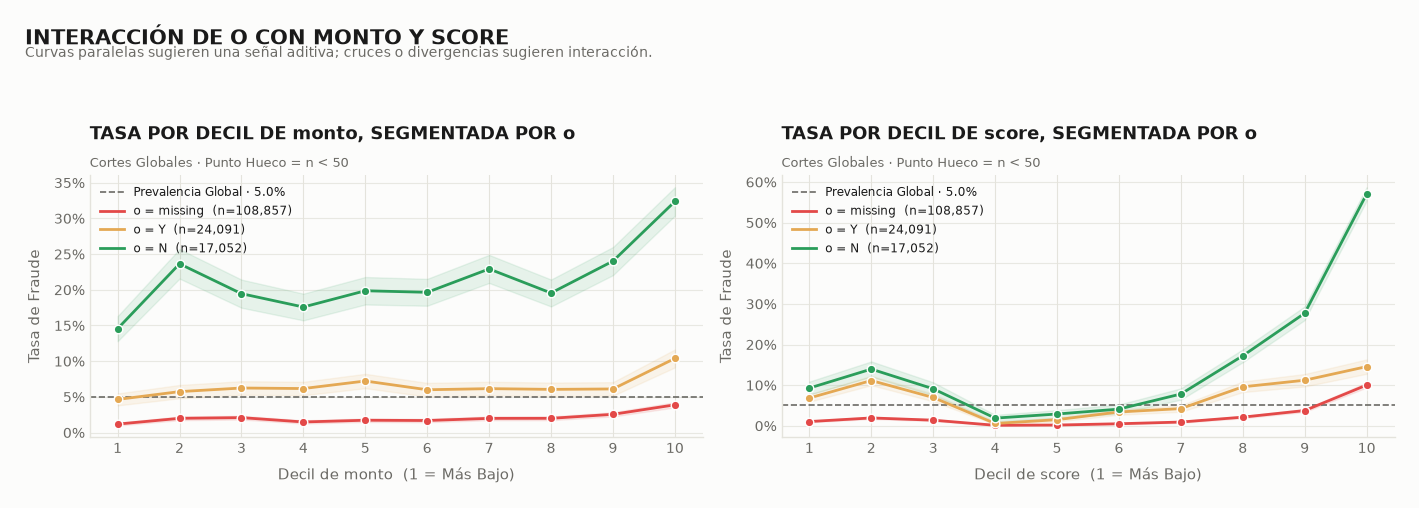

,mean,count
o,,
N,21.75%,"17,052"
Y,6.45%,"24,091"
missing,2.05%,"108,857"


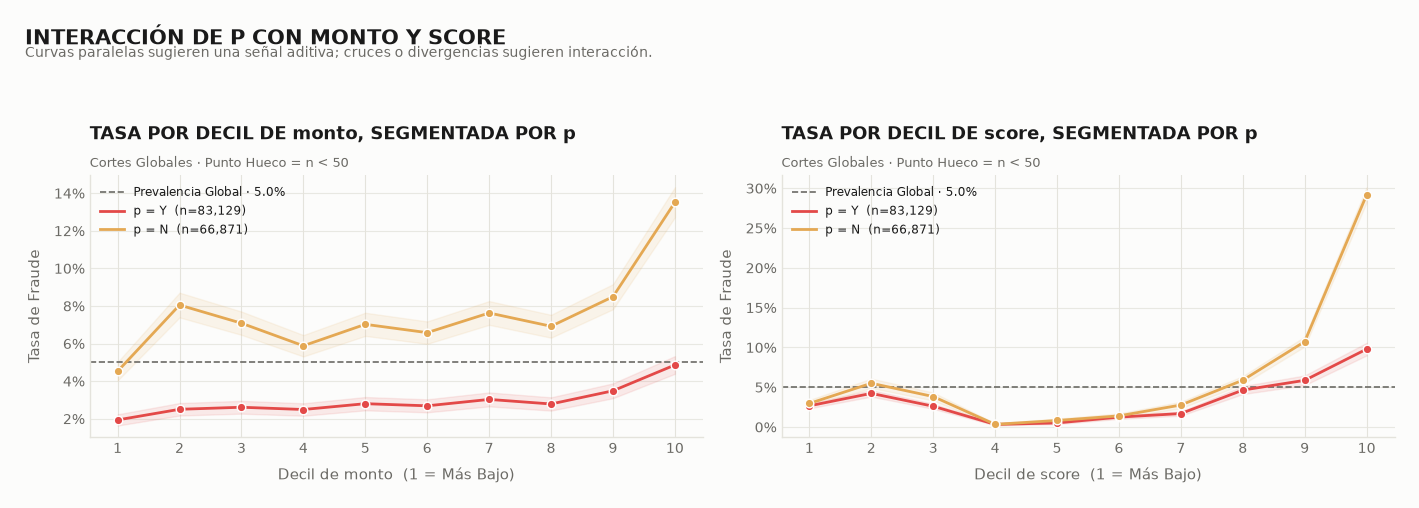

,mean,count
p,,
N,7.60%,"66,871"
Y,2.91%,"83,129"


In [19]:
cols_to_evaluate = ['a', 'n', 'o', 'p']
palette = [COLOR_FRAUD, COLORS['amber'], COLOR_NORMAL, '#2C3E50', '#8E44AD']

for cat_col in cols_to_evaluate:
    cat_segment = raw_df[cat_col].fillna('missing').astype(str)
    unique_levels = cat_segment.unique()
    segment_style = {}
    for i, level in enumerate(unique_levels):
        color = palette[i % len(palette)]
        segment_style[level] = (color, f'{cat_col} = {level}')
    segments_present = {
        key: value for key, value in segment_style.items()
        if key in set(cat_segment)
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    for ax, column in zip(axes, ['monto', 'score']):
        plot_interaction_panel(
            ax, raw_df, cat_segment, column, segments_present,
            title    = f'TASA POR DECIL DE {column}, SEGMENTADA POR {cat_col}',
            subtitle = 'Cortes Globales · Punto Hueco = n < 50',
        )
    finish_figure(
        fig,
        f'INTERACCIÓN DE {cat_col.upper()} CON MONTO Y SCORE',
        'Curvas paralelas sugieren una señal aditiva; cruces o divergencias sugieren interacción.',
        f'4_2_INTERACCION_{cat_col}.png'
    )

    table = (
        category_frame.groupby(cat_col, observed=True, dropna=False)['fraude']
        .agg(mean='mean', count='count')
        .sort_values('mean', ascending=False)
    )
    display_table(
        table,
        caption = f'SOPORTE GLOBAL DE LOS SEGMENTOS DE {cat_col}',
        formats = {'mean': '{:.2%}', 'count': '{:,.0f}'},
    )

___
### 🕘 *4.3 Tendencias por Hora y Día*

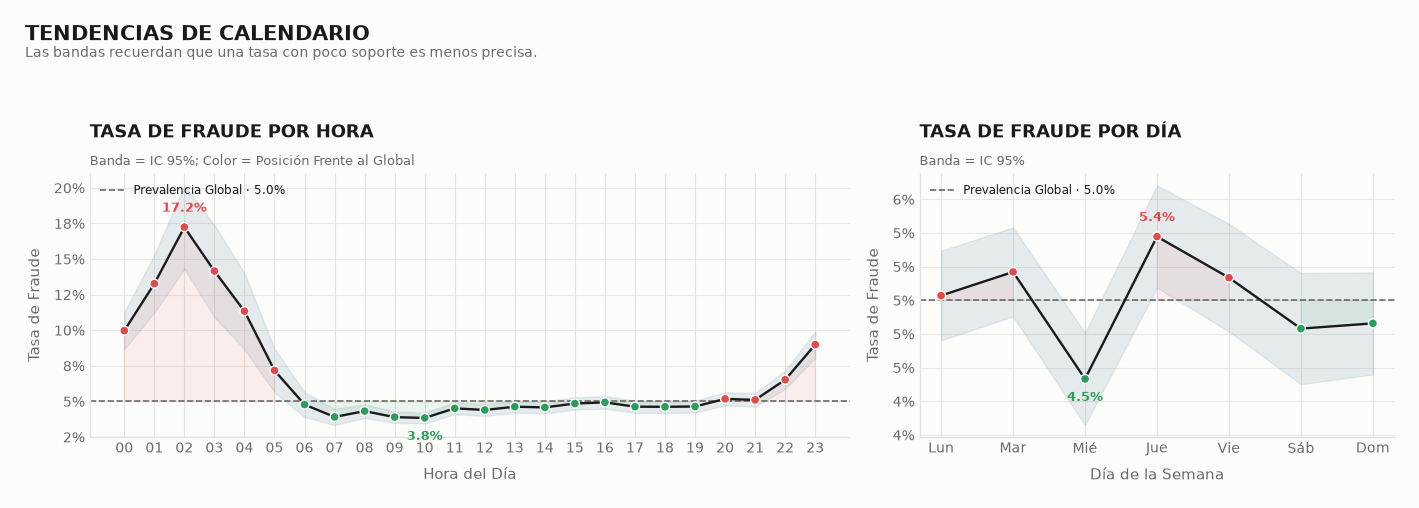

In [20]:
dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
hour_rates = rate_ci(raw_df, '_hour').reindex(range(24))
dow_rates  = rate_ci(raw_df, '_dow').reindex(range(7))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.6, 1]})
plot_trend(
    axes[0], [f'{hour:02d}' for hour in range(24)], hour_rates,
    'TASA DE FRAUDE POR HORA',
    'Banda = IC 95%; Color = Posición Frente al Global',
    'Hora del Día',
)
plot_trend(
    axes[1], dow_labels, dow_rates,
    'TASA DE FRAUDE POR DÍA',
    'Banda = IC 95%',
    'Día de la Semana',
)
finish_figure(
    fig, 'TENDENCIAS DE CALENDARIO',
    'Las bandas recuerdan que una tasa con poco soporte es menos precisa.',
    '4_3_TENDENCIAS_CALENDARIO.png'
)

___
### 🧪 *4.4 Señal Univariada con PR-AUC*


,PR-AUC Univariado
l,0.0341
m,0.0358
f,0.0362
d,0.0390
h,0.0438
e,0.0476
_dow,0.0496
k,0.0503
_hour,0.0549
c,0.0563


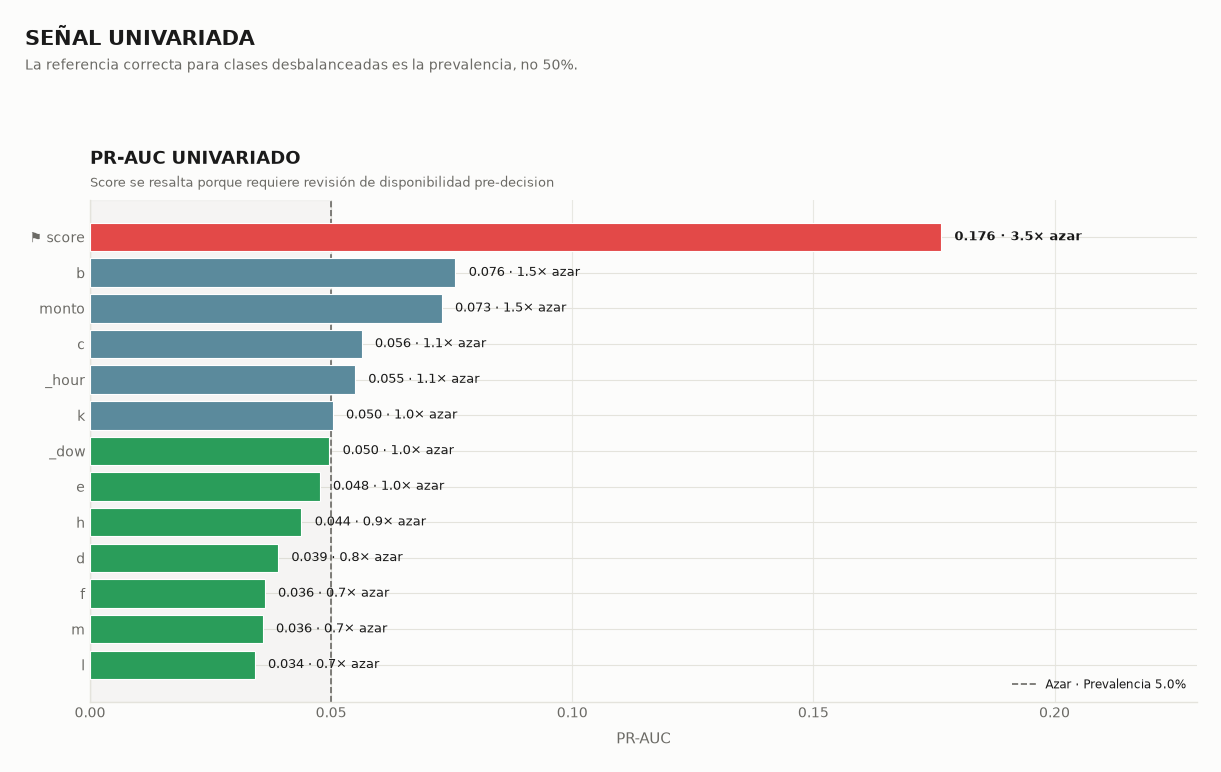

In [21]:
univariate_scores = {}
for column in numerical_cols:
    valid = raw_df[column].notna()
    if raw_df.loc[valid, 'fraude'].nunique() < 2:
        continue
    univariate_scores[column] = average_precision_score(
        raw_df.loc[valid, 'fraude'], raw_df.loc[valid, column]
    )
univariate_scores = pd.Series(
    univariate_scores, name = 'PR-AUC Univariado'
).sort_values()
display_table(
    univariate_scores.to_frame(),
    caption = 'PR-AUC DE CADA FEATURE AISLADA',
    formats = {'PR-AUC Univariado': '{:.4f}'},
)

order    = univariate_scores
y_values = np.arange(len(order))
lift     = order.to_numpy() / BASE_PREVALENCE
x_max    = max(order.max() * 1.30, BASE_PREVALENCE * 2)
bar_colors = [
    COLOR_FRAUD if feature == 'score' else (
        COLOR_NORMAL if value <= BASE_PREVALENCE else COLOR_TEAL
    )
    for feature, value in order.items()
]

fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * len(order) + 2)))
ax.axvspan(0, BASE_PREVALENCE, color=COLOR_GRAY, alpha=0.10)
ax.axvline(BASE_PREVALENCE, color=COLOR_MUTED, linestyle='--', linewidth=1.2, label=f'Azar · Prevalencia {BASE_PREVALENCE:.1%}')
ax.barh(y_values, order.values, color=bar_colors,
        edgecolor='white', linewidth=0.8, zorder=3)
for y_value, (feature, value), feature_lift in zip(
    y_values, order.items(), lift
):
    ax.text(value + x_max * 0.012, y_value,
            f'{value:.3f} · {feature_lift:.1f}× azar',
            va='center', fontsize=9,
            weight='bold' if feature == 'score' else 'normal')
ax.set_yticks(y_values, [
    f'⚑ {feature}' if feature == 'score' else feature
    for feature in order.index
])
ax.set_xlim(0, x_max)
ax.legend(loc = 'lower right', fontsize = 8.5)
finish_ax(ax, title = 'PR-AUC UNIVARIADO', subtitle = 'Score se resalta porque requiere revisión de disponibilidad pre-decision', xlabel = 'PR-AUC', grid = 'x')
finish_figure(
    fig, 'SEÑAL UNIVARIADA',
    'La referencia correcta para clases desbalanceadas es la prevalencia, no 50%.',
    '4_4_PR_AUC_UNIVARIADO.png'
)

___
___
## **⏱️ 5. Estabilidad Temporal y Ventanas del Split**

> - En **5.1 PSI**, todas las variables quedan por debajo de **0,10**. `score` tiene el máximo (**0,0761**) y debe monitorearse porque también concentra la señal; `k` tiene **0,0003**, por lo que su distribución permanece estable entre mitades temporales.
> - En **5.2 Volumen y Prevalencia Diaria**, el volumen cambia por fecha y la tasa presenta picos y caídas puntuales; las bandas de confianza ayudan a distinguir variación muestral de cambios persistentes.
> - El split temporal tiene **97.243 filas y 5,16%** de fraude en train, **23.771 y 5,22%** en validación, y **28.986 y 4,27%** en test. La menor prevalencia de test debe conservarse como referencia al comparar modelos.

___
### 📉 *5.1 Drift Temporal con PSI*

,PSI
score,0.0761
monto,0.0219
_dow,0.0215
b,0.0167
e,0.0100
_hour,0.0089
h,0.0088
d,0.0050
f,0.0041
c,0.0035


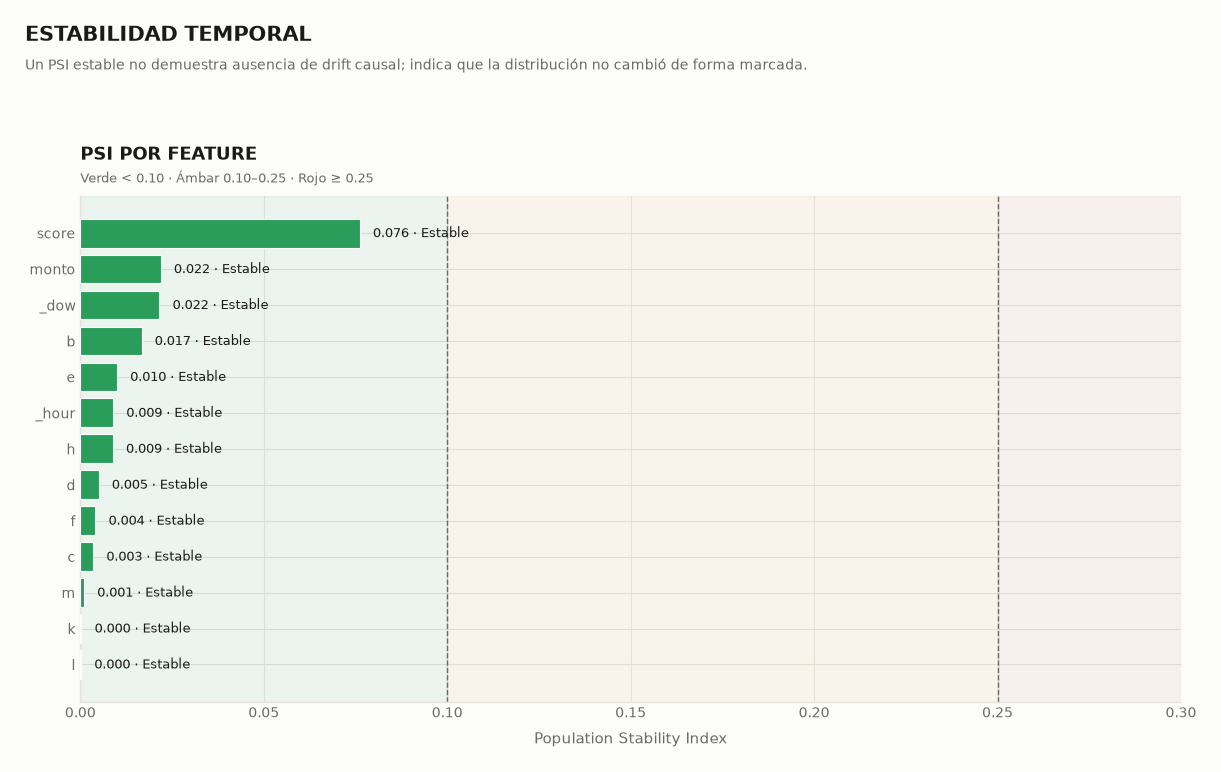

In [22]:
psi_cols    = numerical_cols
median_date = raw_df['_fecha_dt'].median()
early       = raw_df.loc[raw_df['_fecha_dt'] < median_date]
late        = raw_df.loc[raw_df['_fecha_dt'] >= median_date]
psi_table   = pd.Series({
    column: psi(early[column].dropna(), late[column].dropna())
    for column in psi_cols
}, name='PSI').sort_values(ascending=False)
display_table(psi_table.to_frame(), caption='PSI: Primera mitad vs. Segunda mitad', formats={'PSI': '{:.4f}'})

def psi_color(value):
    return COLOR_NORMAL if value < 0.10 else COLORS['amber'] if value < 0.25 else COLORS['id_like']
def psi_label(value):
    return 'Estable' if value < 0.10 else 'Moderado' if value < 0.25 else 'Severo'

ordered  = psi_table.sort_values()
y_values = np.arange(len(ordered))
x_max    = max(float(ordered.max()) * 1.35, 0.30)

fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * len(ordered) + 2)))
ax.axvspan(0, 0.10, color=COLOR_NORMAL, alpha=0.08)
ax.axvspan(0.10, 0.25, color=COLORS['amber'], alpha=0.09)
ax.axvspan(0.25, x_max, color=COLORS['id_like'], alpha=0.09)
for threshold in [0.10, 0.25]:
    ax.axvline(threshold, color=COLOR_MUTED, linestyle='--', linewidth=1.0)
ax.barh(y_values, ordered.values, color=[psi_color(value) for value in ordered.values], edgecolor='white', linewidth=0.8, zorder=3)
for y_value, value in zip(y_values, ordered.values):
    ax.text(value + x_max * 0.012, y_value, f'{value:.3f} · {psi_label(value)}', va='center', fontsize=9, weight='bold' if value >= 0.10 else 'normal')
ax.set_yticks(y_values, ordered.index)
ax.set_xlim(0, x_max)
finish_ax(ax, title = 'PSI POR FEATURE', subtitle = 'Verde < 0.10 · Ámbar 0.10–0.25 · Rojo ≥ 0.25', xlabel = 'Population Stability Index', grid='x')
finish_figure(
    fig, 'ESTABILIDAD TEMPORAL',
    'Un PSI estable no demuestra ausencia de drift causal; indica que la distribución no cambió de forma marcada.',
    '5_1_PSI.png'
)

___
### 🗓️ *5.2 Volumen Diario, Prevalencia y Ventanas*

,Dias,Filas,Fraudes,prevalencia
split,,,,
train,nan,"97,243","5,020",0.051623
valid,nan,"23,771","1,242",0.052249
test,nan,"28,986","1,238",0.042710


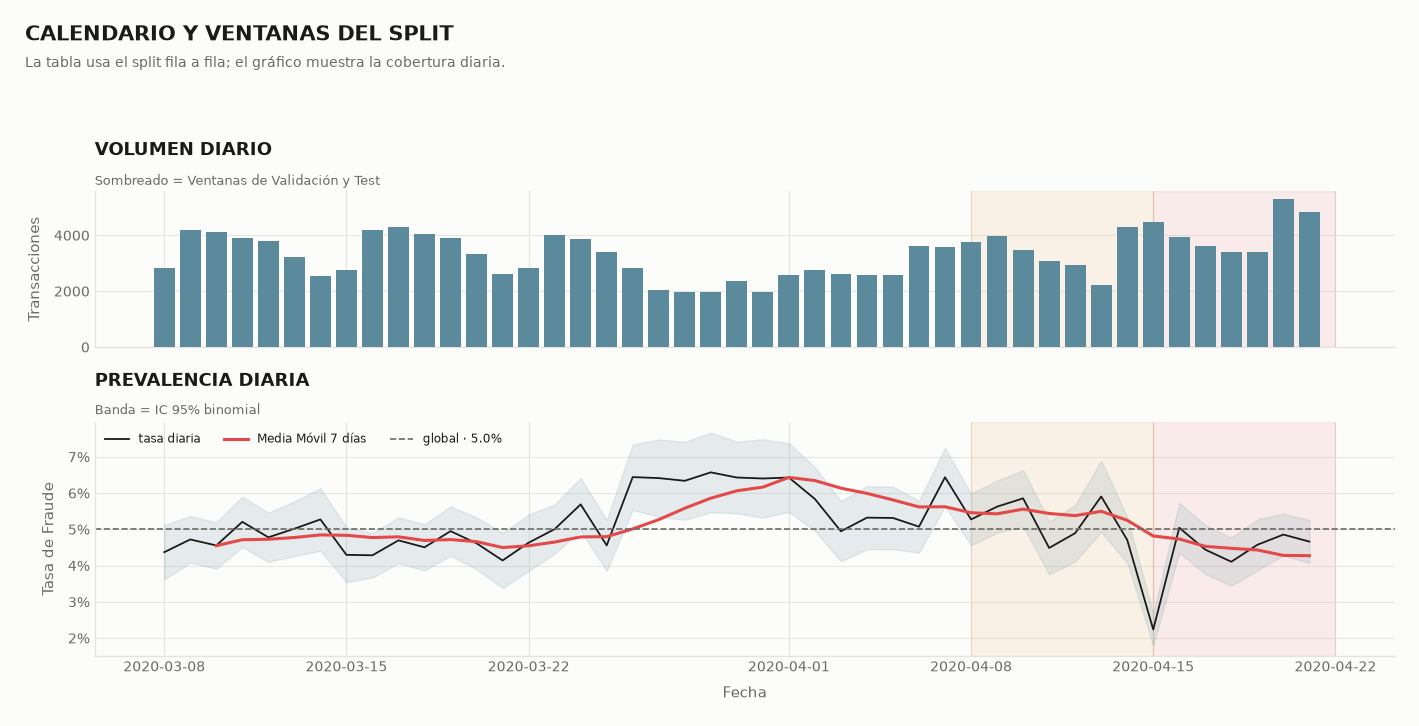

In [23]:
split_summary = (
    split_preview.assign(split=split_preview['dataset_type'].str.lower())
    .groupby('split')['fraude']
    .agg(Dias=lambda series: np.nan, Filas='size', Fraudes='sum')
)
split_summary['prevalencia'] = split_summary['Fraudes'] / split_summary['Filas']
display_table(
    split_summary.reindex(['train', 'valid', 'test']),
    caption = 'SOPORTE EXACTO POR PARTICIÓN',
    formats = {'Filas': '{:,.0f}', 'Fraudes': '{:,.0f}', 'Prevalencia': '{:.2%}'},
)

daily = (
    raw_df.set_index('_fecha_dt')['fraude']
    .resample('D')
    .agg(n='size', fraudes='sum', tasa='mean')
)
daily['se'] = np.sqrt(
    daily['tasa'] * (1 - daily['tasa']) / daily['n'].clip(lower=1)
)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 1.5]},
)
for ax in [ax_top, ax_bottom]:
    ax.axvspan(split_boundaries.valid_start, split_boundaries.test_start, color=COLORS['amber'], alpha=0.12)
    ax.axvspan(split_boundaries.test_start , split_boundaries.test_end  , color=COLOR_FRAUD, alpha=0.09)

ax_top.bar(daily.index, daily['n'], color=COLOR_TEAL, width=0.8, zorder=3)
finish_ax(ax_top, title = 'VOLUMEN DIARIO', subtitle = 'Sombreado = Ventanas de Validación y Test', ylabel = 'Transacciones', grid='y')

rates = daily['tasa']
confidence = 1.96 * daily['se']
ax_bottom.fill_between(
    daily.index, rates - confidence, rates + confidence,
    color=COLOR_TEAL, alpha=0.14,
)
ax_bottom.plot(daily.index, rates, color=COLORS['ink'], linewidth=1.3, label='tasa diaria')
ax_bottom.plot(daily.index, rates.rolling(7, min_periods=3).mean(), color=COLOR_FRAUD, linewidth=2.2, label = 'Media Móvil 7 días')
ax_bottom.axhline(BASE_PREVALENCE, color=COLOR_MUTED, linestyle='--', linewidth=1.2, label=f'global · {BASE_PREVALENCE:.1%}')
ax_bottom.yaxis.set_major_formatter(PCT)
ax_bottom.legend(loc='upper left', fontsize=8.5, ncol=3)
finish_ax(ax_bottom, title = 'PREVALENCIA DIARIA', subtitle = 'Banda = IC 95% binomial', xlabel = 'Fecha', ylabel = 'Tasa de Fraude', grid = 'y')
finish_figure(
    fig, 'CALENDARIO Y VENTANAS DEL SPLIT',
    'La tabla usa el split fila a fila; el gráfico muestra la cobertura diaria.',
    '5_2_SERIE_TEMPORAL_SPLIT.png'
)

___
___
## **🔗 6. Asociaciones, Correlaciones y Redundancia**

> - En **6.1 Asociación con el Target**, `o` obtiene el mayor Cramér’s V (**0,285**) y `j` queda muy cerca (**0,278**), seguidas por `n` (**0,168**) y `p` (**0,107**). Entre numéricas, `score` tiene la correlación positiva más alta (**+0,173**), mientras `l` (**−0,117**) y `m` (**−0,093**) presentan las asociaciones negativas más fuertes.
> - `k` queda prácticamente neutra frente al target (**Pearson +0,002**), coherente con su PR-AUC cercana a la base; esta evidencia respalda incluirla sin atribuirle capacidad predictiva especial.
> - En **6.2 Multicolinealidad**, la única pareja que supera el umbral fuerte de **|ρ| ≥ 0,70** es `m`–`d` (**0,735**). También se observan asociaciones relevantes en `l`–`f` (**0,669**) y `monto`–`e` (**0,652**); deben vigilarse en modelos lineales, pero no obligan a eliminar variables durante el EDA.

___
### 🎯 *6.1 Asociación de Cada Feature con Fraude*

,Pearson
l,-0.117
m,-0.093
d,-0.078
h,-0.035
f,-0.010
_hour,-0.005
e,-0.002
_dow,-0.002
k,+0.002
c,+0.033


,Cramérs V
g,0.054
a,0.062
p,0.107
n,0.168
j,0.278
o,0.285


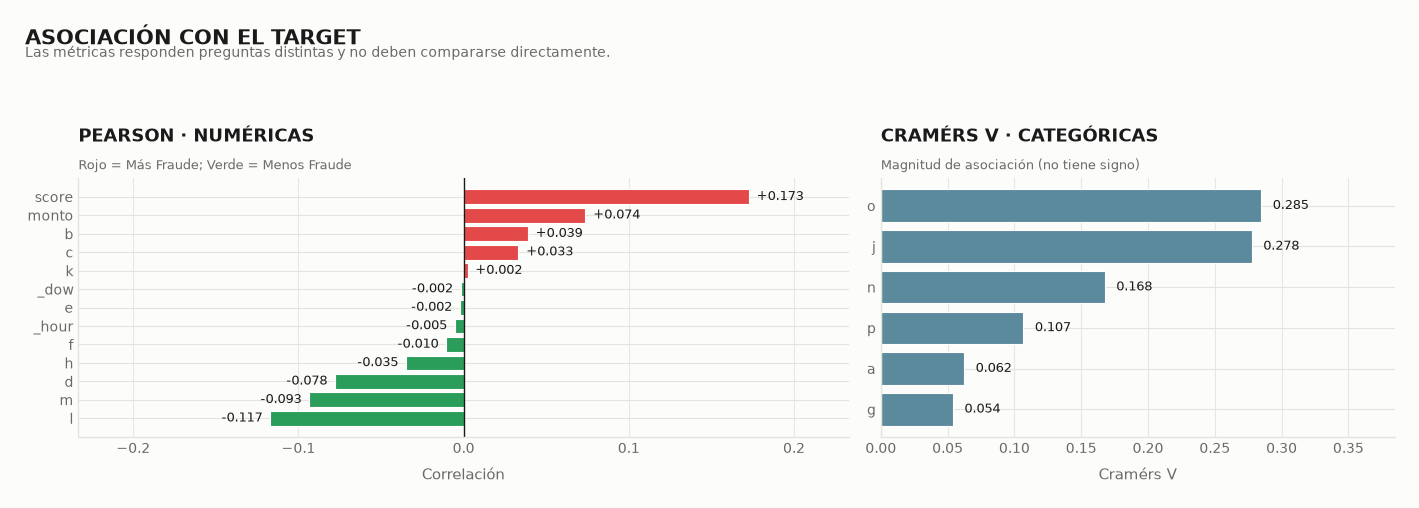

In [24]:
corr_numeric = (
    raw_df[numerical_cols + ['fraude']]
    .corr(numeric_only=True)['fraude']
    .drop('fraude')
    .sort_values()
)
cramers = pd.Series({
    column: cramers_v(raw_df[column], raw_df['fraude'])
    for column in categorical_cols
}, name = 'Cramérs V').sort_values()

display_table(corr_numeric.to_frame('Pearson'), caption = 'CORRELACIÓN DE PEARSON VS. FRAUDE', formats = {'Pearson': '{:+.3f}'})
display_table(cramers.to_frame(), caption = 'CRAMÉRS V VS. FRAUDE', formats = {'Cramérs V': '{:.3f}'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.5, 1]})
ax = axes[0]
y_values = np.arange(len(corr_numeric))
ax.barh(
    y_values, corr_numeric.values,
    color=[COLOR_FRAUD if value > 0 else COLOR_NORMAL for value in corr_numeric.values],
    edgecolor='white', linewidth=0.8,
)
ax.axvline(0, color=COLORS['ink'], linewidth=1.0)
limit = max(abs(corr_numeric.min()), abs(corr_numeric.max())) * 1.35
for y_value, value in zip(y_values, corr_numeric.values):
    ax.text(value + (limit * 0.02 if value >= 0 else -limit * 0.02),
            y_value, f'{value:+.3f}',
            ha='left' if value >= 0 else 'right', va='center', fontsize=9)
ax.set_yticks(y_values, corr_numeric.index)
ax.set_xlim(-limit, limit)
finish_ax(ax, title = 'PEARSON · NUMÉRICAS', subtitle = 'Rojo = Más Fraude; Verde = Menos Fraude', xlabel = 'Correlación', grid = 'x')

ax = axes[1]
y_values = np.arange(len(cramers))
ax.barh(y_values, cramers.values, color=COLOR_TEAL,
        edgecolor='white', linewidth=0.8)
for y_value, value in zip(y_values, cramers.values):
    ax.text(value + max(cramers.max(), 0.01) * 0.03,
            y_value, f'{value:.3f}', va='center', fontsize=9)
ax.set_yticks(y_values, cramers.index)
ax.set_xlim(0, max(cramers.max() * 1.35, 0.1))
finish_ax(ax, title = 'CRAMÉRS V · CATEGÓRICAS', subtitle = 'Magnitud de asociación (no tiene signo)', xlabel = 'Cramérs V', grid = 'x')
finish_figure(
    fig, 'ASOCIACIÓN CON EL TARGET',
    'Las métricas responden preguntas distintas y no deben compararse directamente.',
    '6_1_ASOCIACION_TARGET.png'
)

___
### 🧩 *6.2 Multicolinealidad entre Features*

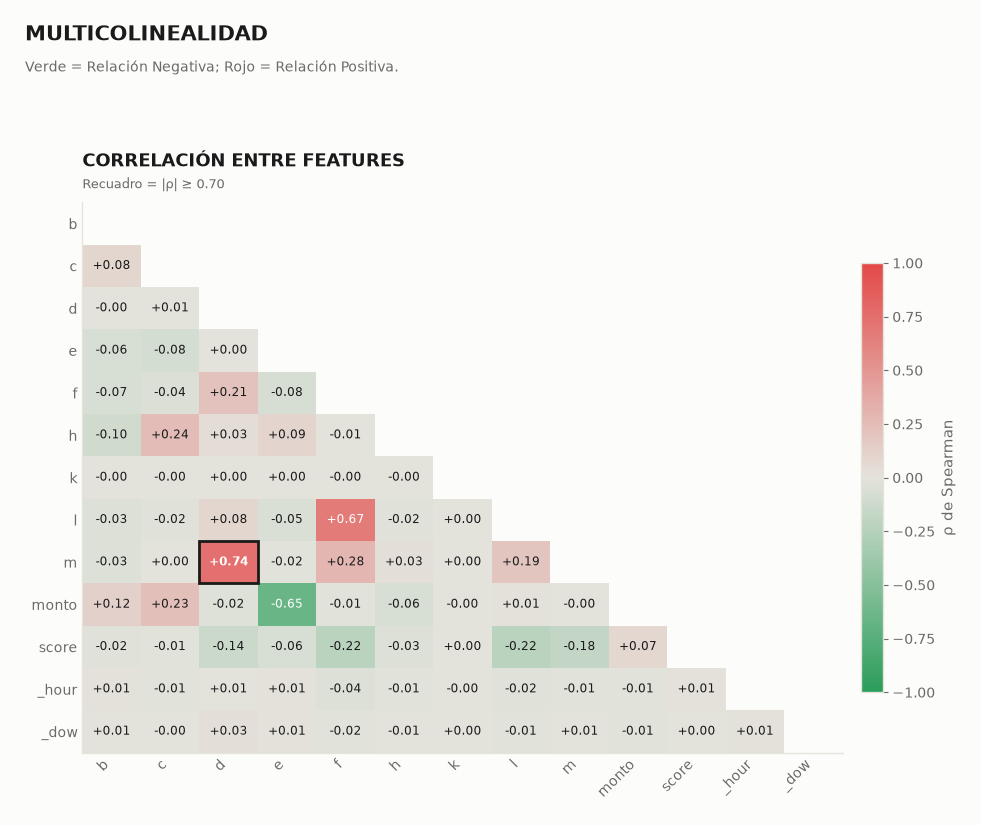

PARES CON |RHO| >= 0.70: 1


In [25]:
corr_features = raw_df[numerical_cols].corr(method = 'spearman')
threshold   = 0.70
upper_mask  = np.triu(np.ones_like(corr_features, dtype=bool))
plot_matrix = np.ma.masked_where(upper_mask, corr_features.to_numpy())

fig, ax = plt.subplots(figsize=(10, 8))
cmap = RISK_CMAP.copy()
cmap.set_bad(COLORS['paper'])
image = ax.imshow(plot_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
feature_count = len(numerical_cols)

for row in range(feature_count):
    for column in range(row):
        value = corr_features.iloc[row, column]
        strong = abs(value) >= threshold
        ax.text(column, row, f'{value:+.2f}',
                ha='center', va='center', fontsize=8.5,
                color='white' if abs(value) >= 0.5 else COLORS['ink'],
                weight='bold' if strong else 'normal')
        if strong:
            ax.add_patch(plt.Rectangle(
                (column - 0.5, row - 0.5), 1, 1,
                fill=False, edgecolor=COLORS['ink'], linewidth=2,
            ))

ax.set_xticks(range(feature_count), numerical_cols, rotation=45, ha='right')
ax.set_yticks(range(feature_count), numerical_cols)
colorbar = fig.colorbar(image, ax=ax, shrink=0.78, pad=0.02)
colorbar.set_label('ρ de Spearman')
finish_ax(ax, title = 'CORRELACIÓN ENTRE FEATURES', subtitle = f'Recuadro = |ρ| ≥ {threshold:.2f}', grid = None)
finish_figure(
    fig, 'MULTICOLINEALIDAD',
    'Verde = Relación Negativa; Rojo = Relación Positiva.',
    '6_2_MULTICOLINEALIDAD.png'
)

redundant_pairs = (
    corr_features.where(~upper_mask)
    .stack()
    .rename('rho')
    .abs()
    .sort_values(ascending=False)
)
display_table(
    redundant_pairs.head(10).to_frame(),
    caption = f'MAYORES ASOCIACIONES ENTRE FEATURES · UMBRAL FUERTE {threshold:.2f}',
    formats = {'rho': '{:.3f}'},
)
print(f'PARES CON |RHO| >= {threshold:.2f}: {(redundant_pairs >= threshold).sum()}')

___
___
## **🧊 8. Congelamiento y Decisión de Features**

> - El manifiesto apunta al `Parquet` limpio de **150.000 filas** y confirma el reparto reproducible de train, validación y test revisado en la sección 5.
> - La tabla de decisión deja **17 features para incluir**, **0 para excluir** y **1 para investigar** (`score`). `k` se habilita como `numeric` con imputación, clipping y escalado robusto porque es un decimal continuo en **[0, 1]**, aunque su PR-AUC sea cercana a la base.
> - `j` queda incluido con encoding OOF por su cardinalidad; `o` conserva su missingness y `g` su agrupación de categorías raras. `score` queda en investigación hasta confirmar disponibilidad pre-decision y significado operativo.
> - El CSV de decisiones funciona como registro auditable para revisar el razonamiento feature por feature y entregar el congelamiento a la etapa de modelado; no es una entrada directa del pipeline.

In [26]:
splitter = TemporalSplitter("fecha", validation_days=7, test_days=7)
builder  = DatasetBuilder(contract, splitter, DATA_ROOT / "processed")
manifest = builder.build(RAW_CSV)

prevalence_str = ", ".join(f"'{k}': {v:.4f}" for k, v in manifest.split.prevalence.items())
print(
    f"📦 Manifiesto del Dataset:\n"
    f"   ├─ Parquet    : {manifest.output_parquet.path}\n"
    f"   ├─ Filas      : {manifest.output_parquet.n_rows:,}\n"
    f"   ├─ Conteos    : {manifest.split.row_counts}\n"
    f"   └─ Prevalencia: {{{prevalence_str}}}"
)

📦 Manifiesto del Dataset:
   ├─ Parquet    : /alloc/data/fury_ads-ctr-item-trigger-fda/fraud_challenge_2026/data/processed/fraud_clean_v1.parquet
   ├─ Filas      : 150,000
   ├─ Conteos    : {'TRAIN': 97243, 'VALID': 23771, 'TEST': 28986}
   └─ Prevalencia: {'TRAIN': 0.0516, 'VALID': 0.0522, 'TEST': 0.0427}


___
### 🧾 *8.1 Tabla incluir / excluir / investigar*

In [27]:
null_pct = raw_df.isna().mean()
decision_table = pd.DataFrame([
    {"feature": "a", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{cardinality['a']} valores únicos; tratar como variable discreta"},
    {"feature": "b", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{null_pct['b']:.2%} nulos; conservar indicador de missing"},
    {"feature": "c", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{null_pct['c']:.2%} nulos; conservar indicador de missing"},
    {"feature": "d", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{null_pct['d']:.2%} nulos"},
    {"feature": "e", "decision": "incluir", "riesgo": "bajo",
     "evidencia": "sin nulos observados"},
    {"feature": "f", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{null_pct['f']:.2%} nulos; tolerancia del contrato"},
    {"feature": "g", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{cardinality['g']} categorías; agrupar cola larga"},
    {"feature": "h", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{cardinality['h']} valores; baja cardinalidad"},
    {"feature": "j", "decision": "incluir", "riesgo": "medio",
     "evidencia": f"{cardinality['j']:,} entidades; encoding OOF y control cold-start"},
    {"feature": "k", "decision": "incluir", "riesgo": "medio",
     "evidencia": f"float en [0, 1]; {cardinality['k']:,}/{len(raw_df):,} valores únicos por precisión decimal; PR-AUC = {univariate_scores['k']:.4f}, PSI = {psi_table['k']:.4f}"},
    {"feature": "l", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{null_pct['l']:.2%} nulos; asociación negativa con fraude"},
    {"feature": "m", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"{null_pct['m']:.2%} nulos; asociación negativa con fraude"},
    {"feature": "n", "decision": "incluir", "riesgo": "bajo",
     "evidencia": "binaria; usar passthrough o tratamiento explícito"},
    {"feature": "o", "decision": "incluir", "riesgo": "medio",
     "evidencia": f"{null_pct['o']:.2%} nulos; missingness y Cramér's V informativos"},
    {"feature": "p", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"Cramér's V = {cramers['p']:.3f}"},
    {"feature": "monto", "decision": "incluir", "riesgo": "bajo",
     "evidencia": f"PR-AUC = {univariate_scores['monto']:.4f}; tendencia interpretable"},
    {"feature": "score", "decision": "investigar", "riesgo": "alto",
     "evidencia": f"PR-AUC = {univariate_scores['score']:.4f}; forma no monotónica y PSI = {psi_table['score']:.4f} (estable, pero debe monitorearse)"},
    {"feature": "fecha", "decision": "incluir", "riesgo": "bajo",
     "evidencia": "define split y permite features cíclicas de calendario"},
])
decision_table.to_csv(
    ARTIFACTS_EDA / "incluir_excluir_investigar_v1.csv", index = False
)
display_table(
    decision_table,
    caption = "DECISIÓN DE FEATURES PARA V1"
)

,feature,decision,riesgo,evidencia
0,a,incluir,bajo,4 valores únicos; tratar como variable discreta
1,b,incluir,bajo,8.66% nulos; conservar indicador de missing
2,c,incluir,bajo,8.66% nulos; conservar indicador de missing
3,d,incluir,bajo,0.24% nulos
4,e,incluir,bajo,sin nulos observados
5,f,incluir,bajo,0.01% nulos; tolerancia del contrato
6,g,incluir,bajo,51 categorías; agrupar cola larga
7,h,incluir,bajo,59 valores; baja cardinalidad
8,j,incluir,medio,"8,324 entidades; encoding OOF y control cold-start"
9,k,incluir,medio,"float en [0, 1]; 150,000/150,000 valores únicos por precisión decimal; PR-AUC = 0.0503, PSI = 0.0003"


> **Artefacto generado:** `artifacts/eda/incluir_excluir_investigar_v1.csv` contiene la decisión y la evidencia resumida de cada feature para auditoría y hand-off al modelado.
